# Hidden Markov Model (HMM) Analysis of Oncocell-Binding Proteins in Maraba Virus

## Overview
This notebook implements and applies a custom Hidden Markov Model (HMM) to investigate whether the Maraba virus (MG1 strain) contains conserved protein motifs associated with oncocell binding and oncolytic behavior.

The core objective is to determine whether sequence-level patterns in viral glycoproteins can be statistically modeled to distinguish oncolytic viruses from non-oncolytic relatives using probabilistic sequence modeling.

---

## Biological Motivation
Oncolytic viruses selectively infect and kill cancer cells. The Maraba virus is a promising oncolytic candidate, but the molecular determinants of its cell-targeting specificity are not fully understood.

Because protein sequence conservation often reflects functional importance, this project uses comparative viral genomics to identify conserved motifs that may contribute to oncocell binding.

---

## Computational Approach
This analysis follows a profile-HMM-based workflow:

1. **Multiple Sequence Alignment (MSA)**  
   Viral protein sequences from oncolytic and non-oncolytic vesiculoviruses are aligned to capture conserved and variable regions.

2. **Custom HMM Construction**  
   A profile Hidden Markov Model is built from aligned sequences, modeling:
   - Match states (conserved residues)
   - Insert states (variable regions)
   - Transition probabilities between states
   - Emission probabilities over amino acids

3. **Sequence Scoring and Inference**  
   Sequences are evaluated under the model using:
   - Log-likelihood scoring
   - Viterbi-style most-likely path inference (where implemented)
   - Comparative scoring between oncolytic and non-oncolytic groups

4. **Proteome Scanning**  
   The trained HMM is applied to broader viral proteomes to identify candidate regions with high model likelihood, suggesting potential oncocell-binding relevance.

5. **Validation**  
   Results are compared against established HMM tools (e.g., pyHMMER) to confirm consistency and biological plausibility.

---

## What This Notebook Demonstrates
- Implementation of probabilistic sequence models from first principles
- Application of HMMs to real biological sequence data
- Comparative genomics and statistical classification of viral proteins
- Integration of biology-driven hypotheses with computational modeling

---

## Tools & Technologies
- Python (NumPy, Pandas)
- Jupyter Notebook
- Hidden Markov Models (HMMs)
- Multiple Sequence Alignment (MSA)
- Comparative Viral Genomics

---

## Author
Aasim Rahim  
BIOL 469 – Genomics  
University of Waterloo

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# Important Global Values
proteinCodes = ["A", "R", "N", "D", "C", "E", "Q", "G", "H", "I", "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V", "-"]

In [ ]:
class HMMState:
    def __init__(self, sProbs, tProbs):
        s = np.array(sProbs, dtype=float)
        if s.sum() == 0:
            s[:] = 1.0
        self.sProbs = s / s.sum()

        t = np.array(tProbs, dtype=float)
        if t.sum() == 0:
            t = np.array([0.9, 0.1])
        self.tProbs = t / t.sum()

    def forward(self):
        emit = np.random.choice(proteinCodes, p=self.sProbs)
        nxt  = 'Match' if np.random.rand() <= self.tProbs[0] else 'Insert'
        return emit, nxt

# ---------- Profile HMM class ----------

class profileHMM:
    def __init__(self):
        self.mStates = []       # list of match states
        self.iState  = None     # global insert state
        self.iSizes  = [1]      # insertion length distribution

    def add_mState(self, mHMMState):
        self.mStates.append(mHMMState)

    def set_insertionInfo(self, iHMMState, iSizes):
        self.iState = iHMMState
        self.iSizes = (iSizes if (iSizes and len(iSizes) > 0) else [1])

    # sample a sequence from the model
    def sample(self):
        out_seq = ""
        for mState in self.mStates:
            emit, nxt = mState.forward()
            out_seq += emit
            while nxt == "Insert":
                L = int(np.random.choice(self.iSizes))
                for _ in range(L):
                    emit2, _ = self.iState.forward()
                    out_seq += emit2
                nxt = "Match"
        return out_seq

    # Viterbi: best log-prob & M/I path for a given (gapless) obs
        # Viterbi: best log-prob & M/I path for a given (gapless) obs
    def mostLikely(self, obs):
        # remove gaps from observation
        obs = ''.join(ch for ch in obs if ch != '-')
        if not self.mStates or not obs:
            return -np.inf, ""

        EPS = 1e-12
        K = len(self.mStates)
        N = len(obs)
        aa2idx = {aa: i for i, aa in enumerate(proteinCodes)}

        def loge(x):
            return np.log(max(float(x), EPS))

        # dpM[i][j]: best logP finishing in Match_j after obs[:i+1]
        # dpI[i][j]: best logP finishing in Insert (after j) after obs[:i+1]
        dpM = [[-np.inf] * K for _ in range(N)]
        dpI = [[-np.inf] * K for _ in range(N)]
        bpM = [[None] * K for _ in range(N)]
        bpI = [[None] * K for _ in range(N)]

        # ----- init at M1 -----
        e0 = aa2idx.get(obs[0], None)
        if e0 is None:
            return -np.inf, ""
        dpM[0][0] = loge(self.mStates[0].sProbs[e0])
        bpM[0][0] = ('M', -1)

        # ----- recursion -----
        for i in range(1, N):
            a = obs[i]
            e = aa2idx.get(a, None)
            if e is None:
                return -np.inf, ""

            # update match states
            for j in range(K):
                best, best_bp = -np.inf, None

                # from previous Match_{j-1} -> Match_j
                if j > 0 and dpM[i-1][j-1] > -np.inf:
                    cand = dpM[i-1][j-1] + loge(self.mStates[j-1].tProbs[0])  # M->M
                    best, best_bp = cand, ('M', j-1)

                # from previous Insert_{j-1} -> Match_j
                if j > 0 and dpI[i-1][j-1] > best:
                    cand = dpI[i-1][j-1] + loge(self.iState.tProbs[0])        # I->M
                    best, best_bp = cand, ('I', j-1)

                if best > -np.inf:
                    dpM[i][j] = best + loge(self.mStates[j].sProbs[e])
                    bpM[i][j] = best_bp

            # update insert states (between j and j+1)
            for j in range(K):
                best, best_bp = -np.inf, None

                # Match_j -> Insert_j
                if dpM[i-1][j] > -np.inf:
                    cand = dpM[i-1][j] + loge(self.mStates[j].tProbs[1])
                    best, best_bp = cand, ('M', j)

                # Insert_j -> Insert_j
                if dpI[i-1][j] > best:
                    cand = dpI[i-1][j] + loge(self.iState.tProbs[1])
                    best, best_bp = cand, ('I', j)

                if best > -np.inf:
                    dpI[i][j] = best + loge(self.iState.sProbs[e])
                    bpI[i][j] = best_bp

        # ----- termination: pick best over ALL j in last position -----
        last = N - 1
        best_log = -np.inf
        end = None
        for j in range(K):
            if dpM[last][j] > best_log:
                best_log = dpM[last][j]
                end = ('M', j)
            if dpI[last][j] > best_log:
                best_log = dpI[last][j]
                end = ('I', j)

        if end is None or best_log == -np.inf:
            # no valid path
            return -np.inf, ""

        # ----- backtrack from the best (tag, j) -----
        path = ['?'] * N
        i = last
        tag, j = end
        while i >= 0:
            path[i] = 'M' if tag == 'M' else 'I'
            if tag == 'M':
                prev = bpM[i][j]
            else:
                prev = bpI[i][j]

            if prev is None:
                break  # safety break; shouldn't normally happen
            tag, j = prev
            i -= 1

        return best_log, ''.join(path)


In [ ]:
# State object used by buildHMM()
class HMMState:
  def __init__(self, sProbs, tProbs):
    # emission over proteinCodes (can include '-')
    self.sProbs = np.array(sProbs, dtype=float)
    self.sProbs = self.sProbs / self.sProbs.sum()

    # transitions: [toMatch, toInsert]
    self.tProbs = np.array(tProbs, dtype=float)
    self.tProbs = self.tProbs / self.tProbs.sum()

  def forward(self):
    # sample one emission + next-state label ('Match' or 'Insert')
    emit = np.random.choice(proteinCodes, p=self.sProbs)
    nxt  = 'Match' if np.random.rand() <= self.tProbs[0] else 'Insert'
    return emit, nxt


In [ ]:
def buildHMM(seqDF):
    H = profileHMM()
    nseq, ncol = seqDF.shape

    # label columns as Match (M) or Insert (I)
    colStates = []
    for c in range(ncol):
        ngaps = (seqDF.iloc[:, c] == "-").sum()
        colStates.append("I" if ngaps > (nseq/2) else "M")

    # insertion sizes
    insertionSizes = []
    for r in range(nseq):
        cur = seqDF.iloc[r, :]
        run = 0
        for c in range(ncol):
            if colStates[c] == "I" and cur[c] != "-":
                run += 1
            else:
                if run > 0:
                    insertionSizes.append(run)
                    run = 0

    numInsertions = len(insertionSizes)
    insertionSites = sum(1 for s in colStates if s == "M")
    denom = insertionSites * nseq if insertionSites * nseq else 1
    defaultInsertionProb = float(np.clip(numInsertions / denom, 1e-9, 1-1e-9))

    # insertion emissions (from all I columns)
    insCols = [c for c in range(ncol) if colStates[c] == "I"]
    if insCols:
        vals = seqDF.iloc[:, insCols].values.flatten().tolist()
        vals = [v for v in vals if v != "-"]
    else:
        vals = []

    if vals:
        counts = [sum(1 for v in vals if v == aa) for aa in proteinCodes]
    else:
        counts = [1]*len(proteinCodes)   # flat prior if no insertion data

    total = float(sum(counts))
    insertion_sProbs = [c/total for c in counts]
    insertion_tProbs = [1-defaultInsertionProb, defaultInsertionProb]

    iState = HMMState(insertion_sProbs, insertion_tProbs)
    H.set_insertionInfo(iState, insertionSizes)

    # match states
    for c in range(ncol):
        if colStates[c] != "M":
            continue

        col = seqDF.iloc[:, c]
        sProbs = [(col == aa).sum() / nseq for aa in proteinCodes]

        # default transitions
        tProbs = [1-defaultInsertionProb, defaultInsertionProb]

        # if next is an insert column, refine insert prob from data
        if c < ncol - 1 and colStates[c+1] == "I":
            nextCol = seqDF.iloc[:, c+1]
            iProb = sum(1 for v in nextCol if v != "-") / nseq
            tProbs = [1-iProb, iProb]

        H.add_mState(HMMState(sProbs, tProbs))

    return H

In [ ]:
# =========================
# SANITY CHECK: build, probs, sample, viterbi
# =========================
import numpy as np
import pandas as pd

# --- data ---
kinAseq = "VAVKTLKDELG--LFRIVN---FPNVGDLKPQKLSDFGLAIEAAK"
kinBseq = "VVIRTLKDELG--VFKLVH---YPNVDDLKPQKLSDFGLSVESVK"
kinCseq = "IAVKALKGDLG--LFRVTDG--LHPGVDLKPQKLSDFGFAIEAVR"
kinDseq = "VVIKALKDELG--LYKVVN---HPNVDVLKPQKLSDFGLAIEAIR"
kinEseq = "LALKVLKDELGNVLFRVVNEE-YPNVNDLKPQKLSDFGLAIEAAR"
kinFseq = "-VLRNLRDDLG--LYKIVN---HPNVEELRPQKLSDFGIAIDAVK"
seqs = [kinAseq, kinBseq, kinCseq, kinDseq, kinEseq, kinFseq]
seqDF = pd.DataFrame(list(seq) for seq in seqs)

# --- helpers ---
def label_cols(df):
    ncol, nseq = df.shape[1], df.shape[0]
    lab = []
    for c in range(ncol):
        ngaps = (df.iloc[:, c] == "-").sum()
        lab.append("I" if ngaps > (nseq/2) else "M")
    return lab

def sums_to_one(vec, tol=1e-8):
    return abs(float(np.sum(vec)) - 1.0) < tol

# --- build model ---
np.random.seed(0)
H = buildHMM(seqDF)
print("✅ buildHMM() ran")

# --- structural check: number of match states ---
labels = label_cols(seqDF)
nM_expected = labels.count("M")
print("Match columns (expected):", nM_expected)
print("Match states  (actual)  :", len(H.mStates))
assert len(H.mStates) == nM_expected, "Mismatch: M states vs labeled M columns"

# --- probability checks ---
# all match states
for i, st in enumerate(H.mStates, 1):
    assert sums_to_one(st.sProbs), f"Match state {i} emission probs do not sum to 1"
    assert sums_to_one(st.tProbs), f"Match state {i} transition probs do not sum to 1"
# insertion state
assert H.iState is not None, "Missing insertion state"
assert sums_to_one(H.iState.sProbs), "Insertion emission probs do not sum to 1"
assert sums_to_one(H.iState.tProbs), "Insertion transition probs do not sum to 1"
print("✅ probability normalization looks good")

# --- insertion sizes sanity ---
if getattr(H, "iSizes", None):
    assert all(isinstance(z, (int, np.integer)) and z > 0 for z in H.iSizes), "Insertion sizes must be positive ints"
    print("Insertion sizes -> count:", len(H.iSizes), "; unique sizes:", sorted(set(H.iSizes))[:10])
else:
    print("Insertion sizes -> none recorded (ok; default should be [1])")

# --- sampling sanity ---
samp = H.sample()
print("sample():", samp)
assert len(samp) > 0, "Sampler returned empty sequence"
valid = set(proteinCodes)
assert all(ch in valid for ch in samp), "Sampler emitted invalid symbols"
print("✅ sample() returned only valid amino acids")

# --- Viterbi: on a true sequence (remove '-') ---
obs1 = kinAseq.replace("-", "")
best_log1, path1 = H.mostLikely(obs1)
print("\nViterbi on kinA (gapless)")
print("  logP:", best_log1)
print("  len(obs), len(path):", len(obs1), len(path1))
print("  path head:", path1[:60])
assert len(obs1) == len(path1), "Path length must match observation length"
assert set(path1) <= {"M","I"}, "Path must contain only 'M' or 'I'"

# --- Viterbi: on a sampled sequence ---
obs2 = samp.replace("-", "")
best_log2, path2 = H.mostLikely(obs2)
print("\nViterbi on sampled sequence")
print("  logP:", best_log2)
print("  len(obs), len(path):", len(obs2), len(path2))
print("  path head:", path2[:60])
assert len(obs2) == len(path2)

# --- Viterbi: force a tiny insertion to see some 'I' if model supports it ---
obs3 = obs1[:12] + "AAA" + obs1[12:]
best_log3, path3 = H.mostLikely(obs3)
print("\nViterbi on kinA + small insertion (AAA)")
print("  logP:", best_log3)
print("  len(obs), len(path):", len(obs3), len(path3))
print("  snippet path around insert:", path3[8:20])
assert len(obs3) == len(path3)

print("\n✅ All sanity checks completed.")

# --- consensus (most likely per-position emission from match states) ---
def consensus_from_model(H, include_gap=False):
    gap_idx = proteinCodes.index('-')
    out = []
    for m in H.mStates:
        probs = m.sProbs.copy()
        if not include_gap:  # ignore '-' as winner
            probs = probs.copy()
            probs[gap_idx] = -1.0
        out.append(proteinCodes[int(np.argmax(probs))])
    return ''.join(out)

# --- compare sample vs consensus, and Viterbi on each ---
cons = consensus_from_model(H)
print("Consensus:", cons)

samp = H.sample()
print("Sample   :", samp)

# Gapless versions for Viterbi
obs_cons  = cons.replace("-", "")
obs_samp  = samp.replace("-", "")

log_cons, path_cons = H.mostLikely(obs_cons)
log_samp, path_samp = H.mostLikely(obs_samp)

print("\nViterbi logP (consensus):", log_cons)




✅ buildHMM() ran
Match columns (expected): 40
Match states  (actual)  : 40
✅ probability normalization looks good
Insertion sizes -> count: 3 ; unique sizes: [1, 2]
sample(): VVLKVLKDDLGLFRVVNHPPVGELKPQKLSDFGLSVEAAR
✅ sample() returned only valid amino acids

Viterbi on kinA (gapless)
  logP: -16.42440775210072
  len(obs), len(path): 40 40
  path head: MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM

Viterbi on sampled sequence
  logP: -22.926697922974665
  len(obs), len(path): 40 40
  path head: MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM

Viterbi on kinA + small insertion (AAA)
  logP: -112.46355100390791
  len(obs), len(path): 43 43
  snippet path around insert: MMMMIIIMMMMM

✅ All sanity checks completed.
Consensus: VAIKALKDELGLFRVVNHPNVDDLKPQKLSDFGLAIEAVR
Sample   : LALKTLRDELGLFKIVDYPPVVDLKPQKLSDFGIAVEIEAIR

Viterbi logP (consensus): -14.227183174764503


In [ ]:
# ==== 1) Paste your MSA here ====
msa_text = r""">YP_009505530.1 glycoprotein [Carajas virus]
MKMKMVIAGLILCIGILPAIGKITISFPQSLKGDWRPVPKGYNYCPTSADKNLHGDLIDI
GLRLRAPKSFKGISADGWMCHAARWITTCDFRWYGPKYITHSIHSFRPSNDQCKEAIRLT
NEGNWINPGFPPQSCGYASVTDSESVVVTVTKHQVLVDEYSGSWIDSQFPGGSCTSPICD
TVHNSTLWHAD-HTLDSICDQEFVAMDAVLFTESGKFEEFGKPNSGIRSNYFPYESLKDV
CQMDFCKRKGFKLPSGVWFEIEDAEKSHKAQVELKIKRCPHGAVISAPNQNAADINLIMD
VERILDYSLCQATWSKIQNKEALTPIDISYLGPKNPGPGPAFTIINGTLHYFNTRYIRVD
IAGPVTKEITGFVS-GTSTSRVLWDQWFPYGENSIGPNGLLKTASGYKYPLFMVGTGVLD
ADIHKLGEATVIEHPHAKEAQKVVDDSEVIFFGDTGVSKNPVEVVEGWFSGWRSSLMSIF
GIILLIVCLVLIVRILIALKYCCVRHKKRTIYKE--------DLEMGRIPRRA-------
----------------------------------
>YP_009362085.1 glycoprotein [Vesiculovirus morreton]
----MLVLYLLLSLLALGAQCKFTIVFPHNQKGNWKNVPANYQYCPSSSDLNWHNGLIGT
SLQVKMPKSHKAIQADGWMCHAAKWVTTCDFRWYGPKYVTHSIKSMIPTVDQCKESIAQT
KQGTWLNPGFPPQSCGYASVTDAEAVIVKATPHQVLVDEYTGEWVDSQFPTGKCNKDICP
TVHNSTTWHSD-YKVTGLCDANLISMDITFFSEDGKLTSLGKEGTGFRSNYFAYENGDKA
CRMQYCKHWGVRLPSGVWFEMADKDIYND----AKFPDCPEGSSIAAPSQTSVDVSLIQD
VERILDYSLCQETWSKIRAHLPISPVDLSYLSPKNPGTGPAFTIINGTLKYFETRYIRVD
IAGPIIPQMRGVIS-GTTTERELWTDWYPYEDVEIGPNGVLKTATGYKFPLYMIGHGMLD
SDLHISSKAQVFEHPHIQDAASQLPDDETLFFGDTGLSKNPIELVEGWFSGWKSTIASFF
FIIGLVIGLYLVLRIGIALCIKCRVQEKRPKIYT--------DVEMNRLDR---------
----------------------------------
>YP_009505535.1 glycoprotein [Piry virus]
---MDLFPILVVVLMTDTVLGKFQIVFPDQNELEWRPVVGDSRHCPQSSEMQFDGSRSQT
ILTGKAPVGITPSKSDGFICHAAKWVTTCDFRWYGPKYITHSIHHLRPTTSDCETALQRY
KDGSLINLGFPPESCGYATVTDSEAMLVQVTPHHVGVDDYRGHWIDPLFPGGECSTNFCD
TVHNSSVWIPKSQ-KTDICAQSFKNIKMTASYPSEGAL--VSDRFAFHSAYHPNMPGSTV
CIMDFCEQKGLRFTNGEWMGLNVEQSIREKKISAIFPNCVAGTEIRATLESEGARTLTWE
TQRMLDYSLCQNTWDKVSRKEPLSPLDLSYLSPRAPGKGMAYTVINGTLHSAHAKYIRTW
IDYGEMKEIKGGRGEYSKAPELLWSQWFDFGPFKIGPNGLLHTGKTFKFPLYLIGAGIID
EDLHELDEAAPIDHPQMPDAKSVLPEDEEIFFGDTGVSKNPIELIQGWFSNWRESVMAIV
GIVLLIVVTFLAIKTVRVLNCLWRPRKKRIVRQEVDVESRLNHFEMRGFPEYVKR-----
----------------------------------
>AEM60937.1 glycoprotein [Vesicular stomatitis virus]
----MNLAVVLCMLLAGSSWAKFTIVFPQSQKGEWRDVPSNYRYCPSSADQSWHGDLLGV
NIRAKIPKAHKAIKADGWMCHAAKWITTCDYRWYGPQYITHSIHSFVPTQAQCEESIKQT
KEGVWINPGFPPKNCGYASINDAESVIVQATAHTVMIDEYSGDWLDSQFPTGRCKGTICE
TIHNSTLWHAD-YKVTGLCDAALVSTEVTFYSEDGLVTSIGRQNTGYRSNYFPYEKGAGA
CRMKYCTHDGIRLPSGVWFEMVDKELLNS----SQMPECPAGLTITAPTQTSVDVSLILD
VERMLDYSLCQETWSKVHNGQPISPVDLGYIAPKNPGAGPAFTIINGTLKYCDTRYLRID
IDGPVLQKMTGKVS-GTPTERELWTEWFPYEDVEIGPNGVLRTQEGYKFPLFMIGHGLLD
ADLQKTSRAEVFHHPQIAEAVKKLPDDETLFFGETGISKNPVELIEGWFSNWRSSVMAVI
FAIVSLVLLGLIVRVIVAFRNSC--CQRKRKVYN--------DLEMNRLRN---------
----------------------------------
>YP_009091829.1 glycoprotein [Maraba virus]
-----MLRLFLFCFLALGAHSKFTIVFPHHQKGNWKNVPSTYHYCPSSSDQNWHNDLTGV
SLHVKIPKSHKAIQADGWMCHAAKWVTTCDFRWYGPKYITHSIHSMSPTLEQCKTSIEQT
KQGVWINPGFPPQSCGYATVTDAEVVVVQATPHHVLVDEYTGEWIDSQLVGGKCSKEVCQ
TVHNSTVWHAD-YKITGLCESNLASVDITFFSEDGQKTSLGKPNTGFRSNHFAYESGEKA
CRMQYCTQWGIRLPSGVWFELVDKDLFQA----AKLPECPRGSSISAPSQTSVDVSLIQD
VERILDYSLCQETWSKIRAKLPVSPVDLSYLAPKNPGSGPAFTIINGTLKYFETRYIRVD
ISNPIIPHMVGTMS-GTTTERELWNDWYPYEDVEIGPNGVLKTPTGFKFPLYMIGHGMLD
SDLHKSSQAQVFEHPHAKDAASQLPDDETLFFGDTGLSKNPVELVEGWFSSWKSTLASFF
LIIGLGVALIFIIRIIVAIRYKYK-GRKTQKIYN--------DVEMSRLGNK--------
----------------------------------
>YP_007641385.1 glycoprotein [Isfahan virus]
-MTSVLFMVGVLLGAFGSTHCSIQIVFPSETKLVWKPVLKGTRYCPQSAELNLEPDLKTM
AFDSKVPIGITPSNSDGYLCHAAKWVTTCDFRWYGPKYITHSVHSLRPTVSDCKAAVEAY
NAGTLMYPGFPPESCGYASITDSEFYVMLVTPHPVGVDDYRGHWVDPLFPTSECNSNFCE
TVHNATMWIPKDLKTHDVCSQDFQTIRVSVMYPQTKPT--KGADLTLKSKFHAHMKGDRV
CKMKFCNKNGLRLGNGEWIEVGDEVMLDNSKLLSLFPDCLVGSVVKSTLLSEGVQTALWE
TDRLLDYSLCQNTWEKIDRKEPLSAVDLSYLAPRSPGKGMAYIVANGSLMSAPARYIRVW
IDSPILKEIKGKKESASGIDTVLWEQWLPFNGMELGPNGLIKTKSGYKFPLYLLGMGIVD
QDLQELSSVNPVDHPHVPIAQAFVSEGEEVFFGDTGVSKNPIELISGWFSDWKETAAALG
FAAISV---ILIIGLMRLLPLLCRRRKQKKVIYK--------DVELNSFDPRQAFHR---
----------------------------------
>YP_009094276.1 glycoprotein [Vesiculovirus bogdanovac]
----MISSTLILVIISAHAFCDMIIPFPDVTTTSWKPVLRGEHHCPASNDLDMAGGLSTL
KMNVKIPSGVVGSKSDGYLCHGAKWVTTCDYRWYGAKYITHSLHPLRPSTSQCFDAIKAY
REGTLLSPGFPPESCGWNSVTDSELLSIQITPHHSGVDDYRGVWIDSMFPKGECDQRICD
TVQEHSIWIAANN-VSSACSIAFKQLEGYFYYRNSGIQP-NKDGTFFHSSHHPNSPMSSC
CRIKYCNQEGLRLHTGEWIGVAWNTKIRDVTLDSYTDTCPGGTEVKSTIGSSPTRVVAWE
MERIMDFALCQNVWDKVNRGEQLSPLDLSYLSSRAPGKGLAYTIINETLHVAHVRYIRTW
IKGPVLKEIKGRRGSSSAAEDTLWIQWFPFGDNQIGPNGLLKSNGTFKFPFYLVGVGALD
EDLIEMANADPVDHLQRVDAETHMRGDEELFFGDTGVSKNPIESVEGWFSNWISGLFNIS
IIVLCVLSVLIVFKSVITLIRVVRRRRRPRAEED---------VELNNMNPRPQTRQPVG
APNIIPGAWGIQPSHGRGVRQSQFVKRSALNIVT
>QNS83659.1 glycoprotein [Chandipura virus]
MLSQVTFQLLVVVCLIYRAYSSLSIAFPESTKLDWKPVTKNTRYCPMGGEWFLEPGLQEE
SFPSSTPIGATPSKSDGFLCHAAKWVTTCDFRWYGPKYITHSIHNIKPTRSDCDSALASY
KSGTLINPGFPPDSCGYASVTDSEFLVIMITPHHVGVDDYRGHWVDPLFVGGECDQSYCD
TIHNSSVWIPADTKKKNICGQSFTPLTVTVAYDKTKDI--SAGALVFKSKYHSHMEGART
CRLTYCGRTGIKFPNGEWVSLDVKTKIQEKQLLPLFKECPAGTEVRSTLQSDGAQVLTSE
IQRLLDYSLCQNTWEKVDRKEPLSPLDLSYLASKSPGKGLAYTVINGTLSFAHTRYVRMW
IDGPVLKELKGKRESASGIASDIWTQWFKYGDMEIGPNGLLKTKSGYKFPWHLIGMGIVD
NELHELSEANPLDHPQLPHAQSIADDSEEIFFGDTGVSKNPVELVTGWFTSWKESLAAGV
VLILTV---VLIYGVLRCFPVLCIPCKKPKWKKGVE---RSDSFEMRIFKPNNMRARV--
----------------------------------
"""

# ==== 2) Parse FASTA MSA into a DataFrame (seqDF) ====
import re
import pandas as pd

def parse_fasta_msa(msa_str):
    seqs = {}
    name = None

    for raw in msa_str.splitlines():
        line = raw.strip()
        if not line:
            continue

        if line.startswith(">"):
            name = line[1:].strip()
            seqs[name] = ""
            continue

        # skip lines that are only dashes
        if set(line) == {"-"}:
            continue

        # keep letters, dash, and dot
        line = re.sub(r"[^A-Za-z\-.]", "", line)

        seqs[name] += line

    # convert '.' → '-' and uppercase
    seqs = {k: v.replace(".", "-").upper() for k, v in seqs.items()}

    # ---- IMPORTANT FIX: pad all sequences to same length ----
    lengths = [len(v) for v in seqs.values()]
    max_len = max(lengths)
    seqs = {k: v.ljust(max_len, "-") for k, v in seqs.items()}

    # final sanity check
    final_lengths = {len(v) for v in seqs.values()}
    assert len(final_lengths) == 1, f"Padding failed: {final_lengths}"

    # convert to DataFrame
    df = pd.DataFrame([list(v) for v in seqs.values()], index=list(seqs.keys()))
    return df


seqDF = parse_fasta_msa(msa_text)
print("✅ Alignment loaded:", seqDF.shape)
print(seqDF.iloc[:6, :44])

# ==== 3) Run your existing HMM on seqDF ====
# Assumes you already defined: proteinCodes, HMMState, profileHMM, buildHMM, consensus_from_HMM, etc.

H = buildHMM(seqDF)
print("✅ HMM built with", len(H.mStates), "match states")

# Consensus from model (ignoring '-' as a winner)
def consensus_from_HMM(H, proteinCodes):
    gap_idx = proteinCodes.index('-')
    letters = []
    for st in H.mStates:
        probs = st.sProbs.copy()
        probs[gap_idx] = -1.0
        letters.append(proteinCodes[int(np.argmax(probs))])
    return "".join(letters)

cons = consensus_from_HMM(H, proteinCodes)
print("\nCons (first 90):", cons[:90])

# Sample from model
samp = H.sample()
print("Samp (first 90):", samp[:90])

# Viterbi on sample and consensus (gapless)
obs_samp = samp.replace("-", "")
log_samp, path_samp = H.mostLikely(obs_samp)
print("\nViterbi on sample:")
print("  logP:", log_samp)
print("  len(obs):", len(obs_samp), " len(path):", len(path_samp))
print("  path head:", path_samp[:80])

obs_cons = cons.replace("-", "")
log_cons, path_cons = H.mostLikely(obs_cons)
print("\nViterbi on consensus:")
print("  logP:", log_cons)
print("  len(obs):", len(obs_cons), " len(path):", len(path_cons))
print("  path head:", path_cons[:80])


✅ Alignment loaded: (8, 574)
                                                   0  1  2  3  4  5  6  7  8   \
YP_009505530.1 glycoprotein [Carajas virus]         M  K  M  K  M  V  I  A  G   
YP_009362085.1 glycoprotein [Vesiculovirus morr...  -  -  -  -  M  L  V  L  Y   
YP_009505535.1 glycoprotein [Piry virus]            -  -  -  M  D  L  F  P  I   
AEM60937.1 glycoprotein [Vesicular stomatitis v...  -  -  -  -  M  N  L  A  V   
YP_009091829.1 glycoprotein [Maraba virus]          -  -  -  -  -  M  L  R  L   
YP_007641385.1 glycoprotein [Isfahan virus]         -  M  T  S  V  L  F  M  V   

                                                   9   ... 34 35 36 37 38 39  \
YP_009505530.1 glycoprotein [Carajas virus]         L  ...  W  R  P  V  P  K   
YP_009362085.1 glycoprotein [Vesiculovirus morr...  L  ...  W  K  N  V  P  A   
YP_009505535.1 glycoprotein [Piry virus]            L  ...  W  R  P  V  V  G   
AEM60937.1 glycoprotein [Vesicular stomatitis v...  V  ...  W  R  D  V  P  S   
YP_

In [ ]:
# ==== 1) Paste your MSA here ====
msa_text = r""">UXO98197.1 glycoprotein [Puer bat vesiculovirus]
---MCTLQIITV-IIV-SYVTAVPVILPAGRDGKWNDVPNGFRYCPAVGDEYSYGRALSL
QVNLLQPKSKEHEGAEGYLCHVAVYEATCDFRWYGVKYQTQKIRRVAPTEKDCIQRVKNT
VTGRNDWVGFPAFSCNYASVTTEKHSEVVLVPHHVGVDDYQGMFVDPTLRDGSCVQPPCQ
TLYEDTLWLPITDLSRTVPCDLEFHQSRGVINFPAPRAGMSLANIQVSGPTLPTTSLDGS
CHMGICGKWGIRLRSGVWIGFRERPILQGMDLYDTFMHGCRANTTISAGHFNPGALKMIW
DAGRLLGYSLCQKTWDKLDRGDSITPLDLSYLNPVSPGPGLGFMSINGTLKMAKLRFARQ
ELPDGLINNYNKD---EPNPSLFQWQRWVPHGNVLVGPNGITLNGSTVKFPFFMVGVGKL
DSDLTEAESIELLHHHEIAKGQMLHPIDDRYDWSHGGQSGDLIKKVESWFSIPDWVKN-I
GYGLITLCLLILMCSIFSRLCLLK-VRQNRRPNN--------DHGPNRS-DIPMSAS---
------------------FL---------
>YP_009505540.1 glycoprotein [Vesiculovirus radi]
---MISITFVYLIIILSLSWGEMMIPFPDVTTTTWKPVLKGEHHCPSSSDVDILSRMSTL
KLQVRIPTGSVASKSDGLLCHGAKWVTTCDFRWYGSKYITHSLHSIRPTLSQCTEAAKAY
KEGRLMAPGFPPESCGWNSVTDSELLSILVTPHHTGVDDYRGIWIDSMFPGGECKEMVCD
TVQGHTIWMSTSNL--TTACGVAFKQIQGQFYYLNSGHQPNKEGTFFHSPNHPNSPLSTA
CRKKYCNQEGIVIHTGEWIGVPWNTRIRDVQL-DSYTDLCAESTEIKSTIGSAPIRVIAW
EMERVMDFALCQTVWDKVNRGDPLSPLDLSYLSSRAPGKGLAYTIINETLHVAHVRYIRT
YIKAPIMEEIKGSRGDRSAAESVLWTQWFPYGDGEIGPNGLLKTNGSFKFPFYLVGMGAI
DDDLIELSNADPIDHPQKAIASVHLNTDEELFFGNTGSDSNPVEAVEGWFA--SWKSAGI
NMALIVLCVLLVLIFLRSLPALIKLIHRYRVSRSRQTDVELNSINETA--RTGSVGPDII
PGAWRVH---DSGVRQSQFFRNNPRRLGP
>YP_009094387.1 glycoprotein [Vesiculovirus perinet]
MSSKIVLAAICL-CSVQYVACSFQIVFPEFNNAAWLPYLKTSRYCPQSAEMEFERRVSTT
LLSADVPIGVTPTKSDGYLCHAAKWVTTCDFRWYGPKYVTHSIHDLTPAQVDCHEALARY
KAGTLFNPGFPPASCGYATITDSEQKVVMITPHHVGIDDYRGKWIDPIFPGGECTTNYCE
TLHNSSVWLPADEKI-VDICAQTFRKIKVTATYPSEGA-VTKETISLHSAYHPHVPGTGI
CRMTYCSKEGLRLPNGEWLGIFYDNRIKTTDV-RTVFPACPDGLEVKSTLNSDGANTIAW
ETQRMLDYALCQSTWDKVQNKEPLSAVDLSYLSARSPGKGLAYTVINGTLHFAHVRYVRT
WIDGPVLKDLKGSRFDPTAAQKTLWDQWFPFGSNEIGPNGLLKTPKDFKFPLYIIGTGLV
DEDLQELSEAGPIDHPQIPDASGILPNSEQVYYGDTGVSKNPIELIEGWFA--NWKETVM
SIVGLVLLITIVFTVLKCIGTCR----SLRRKRKIEKDIELQEIGPYQP-----------
-TTYRPR----------------------
>YP_009094276.1 glycoprotein [Vesiculovirus bogdanovac]
---MISSTL-ILVIISAHAFCDMIIPFPDVTTTSWKPVLRGEHHCPASNDLDMAGGLSTL
KMNVKIPSGVVGSKSDGYLCHGAKWVTTCDYRWYGAKYITHSLHPLRPSTSQCFDAIKAY
REGTLLSPGFPPESCGWNSVTDSELLSIQITPHHSGVDDYRGVWIDSMFPKGECDQRICD
TVQEHSIWIAANNV--SSACSIAFKQLEGYFYYRNSGIQPNKDGTFFHSSHHPNSPMSSC
CRIKYCNQEGLRLHTGEWIGVAWNTKIRDVTL-DSYTDTCPGGTEVKSTIGSSPTRVVAW
EMERIMDFALCQNVWDKVNRGEQLSPLDLSYLSSRAPGKGLAYTIINETLHVAHVRYIRT
WIKGPVLKEIKGRRGSSSAAEDTLWIQWFPFGDNQIGPNGLLKSNGTFKFPFYLVGVGAL
DEDLIEMANADPVDHLQRVDAETHMRGDEELFFGDTGVSKNPIESVEGWFS--NWISGLF
NISIIVLCVLSVLIVFKSVITLIRVVRRRRRPRA-EEDVELNNMNPRPQTRQPVGAPNII
PGAWGIQPSHGRGVRQSQFVKRSALNIVT
>YP_009094177.1 glycoprotein [Vesiculovirus malpais]
--MESLLKAICVLLLIHCSRCDLPIVFPDQKELLWNPVLKTNRYCPQTREIAPLDKPKTL
KITTGVPVRSPKEKIEGYLCHSGKWVTTCDYRWYGAKYVTHSIHHLKPTDQMCRDAISQY
NGGTLLNPGFPPEVCGYASVTDSELIITLITPHTVGVDDYRGLWIDPSFPNGECNSIVCE
TIHNSTKWVSKGEMP-TDICQQTFTTIKMDVSYPSDTT-SQGSLLSFHSPYHPHISGKDI
CKMSYCGSNGLRLPNGEWFSIINTSKIGNKNL-IDFFSPCKAGVEVRSTLQSEGSQTIAW
ETQRMLDYALCQNTWDKFERGEPLSPLDLNYLAPRVPGKGMAYTIINNTLHSSHAVYRRV
WIEGPIIGEMKGKIESATGVAKEIWAQWFEFGQNKIGPNGVIKTNDGIKFPLYAIGTGLI
DQDIHELSEVSPMDHPHLVHAKKYVSEDDEIYFGDTGVSHNPVEIFSGWFT--NWKEGLM
KFSILVLSILIFYVVIRL-VMCI----PLKCKKERKPRLEFE----LQP-----------
-REWEYSRA--------------------
"""

# ==== 2) Parse FASTA MSA into a DataFrame (seqDF) ====
import re
import pandas as pd

def parse_fasta_msa_with_padding(msa_str):
    seqs = {}
    name = None
    for raw in msa_str.splitlines():
        line = raw.strip()
        if not line:
            continue
        if line.startswith('>'):
            name = line[1:].strip()
            seqs[name] = ""
            continue
        # skip pure '-' separator lines
        if set(line) == {'-'}:
            continue
        # keep only letters, '-' and '.'
        line = re.sub(r'[^A-Za-z\-.]', '', line)
        seqs[name] += line

    # convert '.' to '-' (gap)
    seqs = {k: v.replace('.', '-') for k, v in seqs.items()}

    # pad all sequences to the same length (aligned columns)
    maxL = max(len(v) for v in seqs.values())
    for k in seqs:
        if len(seqs[k]) < maxL:
            seqs[k] = seqs[k] + "-"*(maxL - len(seqs[k]))

    df = pd.DataFrame(list(map(list, seqs.values())),
                      index=list(seqs.keys()))
    return df

seqDF = parse_fasta_msa_with_padding(msa_text)
print("✅ Alignment loaded:", seqDF.shape)
print(seqDF.iloc[:5, :44])   # show first 5 seqs, first 44 columns

# ==== 3) Build HMM from this MSA ====
H = buildHMM(seqDF)
print("\n✅ HMM built with", len(H.mStates), "match states")

# helper for consensus (ignore '-' as winner)
def consensus_from_HMM(H, proteinCodes):
    gap_idx = proteinCodes.index('-')
    letters = []
    for st in H.mStates:
        probs = st.sProbs.copy()
        probs[gap_idx] = -1.0
        letters.append(proteinCodes[int(np.argmax(probs))])
    return "".join(letters)

# consensus sequence
cons = consensus_from_HMM(H, proteinCodes)
print("\nCons (first 90):", cons[:90])

# sample from model
samp = H.sample()
print("Samp (first 90):", samp[:90])

# ==== 4) Viterbi on sample and consensus ====
obs_samp = samp.replace("-", "")
log_samp, path_samp = H.mostLikely(obs_samp)
print("\nViterbi on sample:")
print("  logP:", log_samp)
print("  len(obs):", len(obs_samp), " len(path):", len(path_samp))
print("  path head:", path_samp[:80])

obs_cons = cons.replace("-", "")
log_cons, path_cons = H.mostLikely(obs_cons)
print("\nViterbi on consensus:")
print("  logP:", log_cons)
print("  len(obs):", len(obs_cons), " len(path):", len(path_cons))
print("  path head:", path_cons[:80])


✅ Alignment loaded: (5, 569)
                                                   0  1  2  3  4  5  6  7  8   \
UXO98197.1 glycoprotein [Puer bat vesiculovirus]    -  -  -  M  C  T  L  Q  I   
YP_009505540.1 glycoprotein [Vesiculovirus radi]    -  -  -  M  I  S  I  T  F   
YP_009094387.1 glycoprotein [Vesiculovirus peri...  M  S  S  K  I  V  L  A  A   
YP_009094276.1 glycoprotein [Vesiculovirus bogd...  -  -  -  M  I  S  S  T  L   
YP_009094177.1 glycoprotein [Vesiculovirus malp...  -  -  M  E  S  L  L  K  A   

                                                   9   ... 34 35 36 37 38 39  \
UXO98197.1 glycoprotein [Puer bat vesiculovirus]    I  ...  W  N  D  V  P  N   
YP_009505540.1 glycoprotein [Vesiculovirus radi]    V  ...  W  K  P  V  L  K   
YP_009094387.1 glycoprotein [Vesiculovirus peri...  I  ...  W  L  P  Y  L  K   
YP_009094276.1 glycoprotein [Vesiculovirus bogd...  -  ...  W  K  P  V  L  R   
YP_009094177.1 glycoprotein [Vesiculovirus malp...  I  ...  W  N  P  V  L  K   

   

In [ ]:
msa_text = r""">UXO98197.1 glycoprotein [Puer bat vesiculovirus]
---MCTLQIITV-IIVS-YVTAVPVILPAGRDGKWNDVPNGFRYCPAVGDEYSYGRALSL
QVNLLQPKSKEHEGAEGYLCHVAVYEATCDFRWYGVKYQTQKIRRVAPTEKDCIQRVKNT
VTGRNDWVGFPAFSCNYASVTTEKHSEVVLVPHHVGVDDYQGMFVDPTLRDGSCVQPPCQ
TLYEDTLWLPITDLSRTVPCDLEFHQSRGVINFPAPRAGMSLANIQVSGPTLPTTSLDGS
CHMGICGKWGIRLRSGVWIGFRERPILQGMDLYDTFMHGCRANTTISAGHFNPGALKMIW
DAGRLLGYSLCQKTWDKLDRGDSITPLDLSYLNPVSPGPGLGFMSINGTLKMAKLRFARQ
ELPDGLINNYNKD---EPNPSLFQWQRWVPHGNVLVGPNGITLNGSTVKFPFFMVGVGKL
DSDLTEAESIELLHHHEIAKGQMLHPIDDRYDWSHGGQSGDLIKKVESWFSIPDWVKN-I
GYGLITLCLLILMCSIFSR-LCL-----LKVRQNRRPN---NDHGPNRSDIPMSASFL--
------------------------
>YP_009505540.1 glycoprotein [Vesiculovirus radi]
---MISITFVYLIIILSLSWGEMMIPFPDVTTTTWKPVLKGEHHCPSSSDVDILSRMSTL
KLQVRIPTGSVASKSDGLLCHGAKWVTTCDFRWYGSKYITHSLHSIRPTLSQCTEAAKAY
KEGRLMAPGFPPESCGWNSVTDSELLSILVTPHHTGVDDYRGIWIDSMFPGGECKEMVCD
TVQGHTIWMSTSNL--TTACGVAFKQIQGQFYYLNSGHQPNKEGTFFHSPNHPNSPLSTA
CRKKYCNQEGIVIHTGEWIGVPWNTRIRDVQL-DSYTDLCAESTEIKSTIGSAPIRVIAW
EMERVMDFALCQTVWDKVNRGDPLSPLDLSYLSSRAPGKGLAYTIINETLHVAHVRYIRT
YIKAPIMEEIKGSRGDRSAAESVLWTQWFPYGDGEIGPNGLLKTNGSFKFPFYLVGMGAI
DDDLIELSNADPIDHPQKAIASVHLNTDEELFFGNTGSDSNPVEAVEGWFAS--WKSAGI
NMALIVLCVLLVLIFLRSLPALIKLIHRYRVSRSRQTDVELNSINETARTGSVGPDIIPG
AWRVHDSGVRQSQFFRNNPRRLGP
>YP_009094387.1 glycoprotein [Vesiculovirus perinet]
MSSKIVLAAICL-CSVQYVACSFQIVFPEFNNAAWLPYLKTSRYCPQSAEMEFERRVSTT
LLSADVPIGVTPTKSDGYLCHAAKWVTTCDFRWYGPKYVTHSIHDLTPAQVDCHEALARY
KAGTLFNPGFPPASCGYATITDSEQKVVMITPHHVGIDDYRGKWIDPIFPGGECTTNYCE
TLHNSSVWLPADEKI-VDICAQTFRKIKVTATYPSEGA-VTKETISLHSAYHPHVPGTGI
CRMTYCSKEGLRLPNGEWLGIFYDNRIKTTDV-RTVFPACPDGLEVKSTLNSDGANTIAW
ETQRMLDYALCQSTWDKVQNKEPLSAVDLSYLSARSPGKGLAYTVINGTLHFAHVRYVRT
WIDGPVLKDLKGSRFDPTAAQKTLWDQWFPFGSNEIGPNGLLKTPKDFKFPLYIIGTGLV
DEDLQELSEAGPIDHPQIPDASGILPNSEQVYYGDTGVSKNPIELIEGWFAN--WKETVM
SIVGLVLLITIVFTVLKCIGTCRS----LRRKRKIEKDIELQEIGP----------YQPT
TYRPR-------------------
>YP_009094177.1 glycoprotein [Vesiculovirus malpais]
--MESLLKAICVLLLIHCSRCDLPIVFPDQKELLWNPVLKTNRYCPQTREIAPLDKPKTL
KITTGVPVRSPKEKIEGYLCHSGKWVTTCDYRWYGAKYVTHSIHHLKPTDQMCRDAISQY
NGGTLLNPGFPPEVCGYASVTDSELIITLITPHTVGVDDYRGLWIDPSFPNGECNSIVCE
TIHNSTKWVSKGEMP-TDICQQTFTTIKMDVSYPSDTT-SQGSLLSFHSPYHPHISGKDI
CKMSYCGSNGLRLPNGEWFSIINTSKIGNKNL-IDFFSPCKAGVEVRSTLQSEGSQTIAW
ETQRMLDYALCQNTWDKFERGEPLSPLDLNYLAPRVPGKGMAYTIINNTLHSSHAVYRRV
WIEGPIIGEMKGKIESATGVAKEIWAQWFEFGQNKIGPNGVIKTNDGIKFPLYAIGTGLI
DQDIHELSEVSPMDHPHLVHAKKYVSEDDEIYFGDTGVSHNPVEIFSGWFTN--WKEGLM
KFSILVLSILIFYVVIRL-VMCIP----LKCKKERKPRLEFE--------------LQPR
EWEYSRA-----------------
"""

def parse_fasta_msa(msa_str):
    seqs = {}
    name = None
    for raw in msa_str.splitlines():
        line = raw.strip()
        if not line:
            continue
        if line.startswith('>'):
            name = line[1:].strip()
            seqs[name] = ""
            continue
        # skip pure separator lines like "-----"
        if set(line) == {'-'}:
            continue
        # keep only letters, '-' and '.'
        line = re.sub(r'[^A-Za-z\-.]', '', line)
        seqs[name] += line
    # convert '.' to '-'
    seqs = {k: v.replace('.', '-') for k, v in seqs.items()}

    # pad sequences to same length with '-'
    max_len = max(len(v) for v in seqs.values())
    for k in seqs:
        if len(seqs[k]) < max_len:
            seqs[k] = seqs[k] + "-"*(max_len - len(seqs[k]))

    df = pd.DataFrame(list(map(list, seqs.values())), index=list(seqs.keys()))
    return df

# -----------------------------
# 5) Run everything
# -----------------------------
np.random.seed(0)  # for reproducible sampling

seqDF = parse_fasta_msa(msa_text)
print("✅ Alignment loaded:", seqDF.shape)
print(seqDF.iloc[:5, :44], "\n")  # head

H = buildHMM(seqDF)
print("✅ HMM built with", len(H.mStates), "match states")

# consensus from model (ignore '-' as winner)
def consensus_from_HMM(H, proteinCodes):
    gap_idx = proteinCodes.index('-')
    letters = []
    for st in H.mStates:
        probs = st.sProbs.copy()
        probs[gap_idx] = -1.0   # force ignore gaps
        letters.append(proteinCodes[int(np.argmax(probs))])
    return "".join(letters)

cons = consensus_from_HMM(H, proteinCodes)
print("\nCons (first 90):", cons[:90])

samp = H.sample()
print("Samp (first 90):", samp[:90])

# Viterbi on sample and consensus
obs_samp = samp.replace("-", "")
log_samp, path_samp = H.mostLikely(obs_samp)
print("\nViterbi on sample:")
print("  logP:", log_samp)
print("  len(obs):", len(obs_samp), " len(path):", len(path_samp))
print("  path head:", path_samp[:80])

obs_cons = cons.replace("-", "")
log_cons, path_cons = H.mostLikely(obs_cons)
print("\nViterbi on consensus:")
print("  logP:", log_cons)
print("  len(obs):", len(obs_cons), " len(path):", len(path_cons))
print("  path head:", path_cons[:80])

✅ Alignment loaded: (4, 564)
                                                   0  1  2  3  4  5  6  7  8   \
UXO98197.1 glycoprotein [Puer bat vesiculovirus]    -  -  -  M  C  T  L  Q  I   
YP_009505540.1 glycoprotein [Vesiculovirus radi]    -  -  -  M  I  S  I  T  F   
YP_009094387.1 glycoprotein [Vesiculovirus peri...  M  S  S  K  I  V  L  A  A   
YP_009094177.1 glycoprotein [Vesiculovirus malp...  -  -  M  E  S  L  L  K  A   

                                                   9   ... 34 35 36 37 38 39  \
UXO98197.1 glycoprotein [Puer bat vesiculovirus]    I  ...  W  N  D  V  P  N   
YP_009505540.1 glycoprotein [Vesiculovirus radi]    V  ...  W  K  P  V  L  K   
YP_009094387.1 glycoprotein [Vesiculovirus peri...  I  ...  W  L  P  Y  L  K   
YP_009094177.1 glycoprotein [Vesiculovirus malp...  I  ...  W  N  P  V  L  K   

                                                   40 41 42 43  
UXO98197.1 glycoprotein [Puer bat vesiculovirus]    G  F  R  Y  
YP_009505540.1 glycoprotein [Vesic

In [ ]:
import re
import pandas as pd
import numpy as np

# ---------- 1. Parser for FASTA MSA ----------

def parse_fasta_msa(msa_str):
    seqs = {}
    name = None
    for raw in msa_str.splitlines():
        line = raw.strip()
        if not line:
            continue
        if line.startswith('>'):
            name = line[1:].strip()
            seqs[name] = ""
            continue
        # remove spaces
        line = line.replace(" ", "")
        # skip lines that are only gaps
        if set(line) == {"-"}:
            continue
        # keep only letters and '-'
        line = re.sub(r"[^A-Za-z\-]", "", line)
        seqs[name] += line

    # pad all sequences to the same length with '-'
    max_len = max(len(s) for s in seqs.values())
    for k, v in seqs.items():
        if len(v) < max_len:
            seqs[k] = v + "-" * (max_len - len(v))

    df = pd.DataFrame(list(map(list, seqs.values())), index=list(seqs.keys()))
    return df

# ---------- 2. Your two MSAs ----------

non_onco_msa = r""">UXO98197.1 glycoprotein [Puer bat vesiculovirus]
---MCTLQIITV-IIVS-YVTAVPVILPAGRDGKWNDVPNGFRYCPAVGDEYSYGRALSL
QVNLLQPKSKEHEGAEGYLCHVAVYEATCDFRWYGVKYQTQKIRRVAPTEKDCIQRVKNT
VTGRNDWVGFPAFSCNYASVTTEKHSEVVLVPHHVGVDDYQGMFVDPTLRDGSCVQPPCQ
TLYEDTLWLPITDLSRTVPCDLEFHQSRGVINFPAPRAGMSLANIQVSGPTLPTTSLDGS
CHMGICGKWGIRLRSGVWIGFRERPILQGMDLYDTFMHGCRANTTISAGHFNPGALKMIW
DAGRLLGYSLCQKTWDKLDRGDSITPLDLSYLNPVSPGPGLGFMSINGTLKMAKLRFARQ
ELPDGLINNYNKD---EPNPSLFQWQRWVPHGNVLVGPNGITLNGSTVKFPFFMVGVGKL
DSDLTEAESIELLHHHEIAKGQMLHPIDDRYDWSHGGQSGDLIKKVESWFSIPDWVKN-I
GYGLITLCLLILMCSIFSR-LCL-----LKVRQNRRPN---NDHGPNRSDIPMSASFL--
------------------------
>YP_009505540.1 glycoprotein [Vesiculovirus radi]
---MISITFVYLIIILSLSWGEMMIPFPDVTTTTWKPVLKGEHHCPSSSDVDILSRMSTL
KLQVRIPTGSVASKSDGLLCHGAKWVTTCDFRWYGSKYITHSLHSIRPTLSQCTEAAKAY
KEGRLMAPGFPPESCGWNSVTDSELLSILVTPHHTGVDDYRGIWIDSMFPGGECKEMVCD
TVQGHTIWMSTSNL--TTACGVAFKQIQGQFYYLNSGHQPNKEGTFFHSPNHPNSPLSTA
CRKKYCNQEGIVIHTGEWIGVPWNTRIRDVQL-DSYTDLCAESTEIKSTIGSAPIRVIAW
EMERVMDFALCQTVWDKVNRGDPLSPLDLSYLSSRAPGKGLAYTIINETLHVAHVRYIRT
YIKAPIMEEIKGSRGDRSAAESVLWTQWFPYGDGEIGPNGLLKTNGSFKFPFYLVGMGAI
DDDLIELSNADPIDHPQKAIASVHLNTDEELFFGNTGSDSNPVEAVEGWFAS--WKSAGI
NMALIVLCVLLVLIFLRSLPALIKLIHRYRVSRSRQTDVELNSINETARTGSVGPDIIPG
AWRVHDSGVRQSQFFRNNPRRLGP
>YP_009094387.1 glycoprotein [Vesiculovirus perinet]
MSSKIVLAAICL-CSVQYVACSFQIVFPEFNNAAWLPYLKTSRYCPQSAEMEFERRVSTT
LLSADVPIGVTPTKSDGYLCHAAKWVTTCDFRWYGPKYVTHSIHDLTPAQVDCHEALARY
KAGTLFNPGFPPASCGYATITDSEQKVVMITPHHVGIDDYRGKWIDPIFPGGECTTNYCE
TLHNSSVWLPADEKI-VDICAQTFRKIKVTATYPSEGA-VTKETISLHSAYHPHVPGTGI
CRMTYCSKEGLRLPNGEWLGIFYDNRIKTTDV-RTVFPACPDGLEVKSTLNSDGANTIAW
ETQRMLDYALCQSTWDKVQNKEPLSAVDLSYLSARSPGKGLAYTVINGTLHFAHVRYVRT
WIDGPVLKDLKGSRFDPTAAQKTLWDQWFPFGSNEIGPNGLLKTPKDFKFPLYIIGTGLV
DEDLQELSEAGPIDHPQIPDASGILPNSEQVYYGDTGVSKNPIELIEGWFAN--WKETVM
SIVGLVLLITIVFTVLKCIGTCRS----LRRKRKIEKDIELQEIGP----------YQPT
TYRPR-------------------
>YP_009094177.1 glycoprotein [Vesiculovirus malpais]
--MESLLKAICVLLLIHCSRCDLPIVFPDQKELLWNPVLKTNRYCPQTREIAPLDKPKTL
KITTGVPVRSPKEKIEGYLCHSGKWVTTCDYRWYGAKYVTHSIHHLKPTDQMCRDAISQY
NGGTLLNPGFPPEVCGYASVTDSELIITLITPHTVGVDDYRGLWIDPSFPNGECNSIVCE
TIHNSTKWVSKGEMP-TDICQQTFTTIKMDVSYPSDTT-SQGSLLSFHSPYHPHISGKDI
CKMSYCGSNGLRLPNGEWFSIINTSKIGNKNL-IDFFSPCKAGVEVRSTLQSEGSQTIAW
ETQRMLDYALCQNTWDKFERGEPLSPLDLNYLAPRVPGKGMAYTIINNTLHSSHAVYRRV
WIEGPIIGEMKGKIESATGVAKEIWAQWFEFGQNKIGPNGVIKTNDGIKFPLYAIGTGLI
DQDIHELSEVSPMDHPHLVHAKKYVSEDDEIYFGDTGVSHNPVEIFSGWFTN--WKEGLM
KFSILVLSILIFYVVIRL-VMCIP----LKCKKERKPRLEFE--------------LQPR
EWEYSRA-----------------
"""

onco_msa = r""">YP_009505530.1 glycoprotein [Carajas virus]
MKMKMVIAGLILCIGILPAIGKITISFPQSLKGDWRPVPKGYNYCPTSADKNLHGDLIDI
GLRLRAPKSFKGISADGWMCHAARWITTCDFRWYGPKYITHSIHSFRPSNDQCKEAIRLT
NEGNWINPGFPPQSCGYASVTDSESVVVTVTKHQVLVDEYSGSWIDSQFPGGSCTSPICD
TVHNSTLWHA-DHTLDSICDQEFVAMDAVLFTESGKFEEFGKPNSGIRSNYFPYESLKDV
CQMDFCKRKGFKLPSGVWFEIEDAEKSHKAQVELKIKRCPHGAVISAPNQNAADINLIMD
VERILDYSLCQATWSKIQNKEALTPIDISYLGPKNPGPGPAFTIINGTLHYFNTRYIRVD
IAGPVTKEITGFVSG-TSTSRVLWDQWFPYGENSIGPNGLLKTASGYKYPLFMVGTGVLD
ADIHKLGEATVIEHPHAKEAQKVVDDSEVIFFGDTGVSKNPVEVVEGWFSGWRSSLMSIF
GIILLIVCLVLIVRILIALKYCCVRHKKRTIYKE--------DLEMGRIPRRA-----
>YP_009362085.1 glycoprotein [Vesiculovirus morreton]
----MLVLYLLLSLLALGAQCKFTIVFPHNQKGNWKNVPANYQYCPSSSDLNWHNGLIGT
SLQVKMPKSHKAIQADGWMCHAAKWVTTCDFRWYGPKYVTHSIKSMIPTVDQCKESIAQT
KQGTWLNPGFPPQSCGYASVTDAEAVIVKATPHQVLVDEYTGEWVDSQFPTGKCNKDICP
TVHNSTTWHS-DYKVTGLCDANLISMDITFFSEDGKLTSLGKEGTGFRSNYFAYENGDKA
CRMQYCKHWGVRLPSGVWFEMADKDIYND----AKFPDCPEGSSIAAPSQTSVDVSLIQD
VERILDYSLCQETWSKIRAHLPISPVDLSYLSPKNPGTGPAFTIINGTLKYFETRYIRVD
IAGPIIPQMRGVISG-TTTERELWTDWYPYEDVEIGPNGVLKTATGYKFPLYMIGHGMLD
SDLHISSKAQVFEHPHIQDAASQLPDDETLFFGDTGLSKNPIELVEGWFSGWKSTIASFF
FIIGLVIGLYLVLRIGIALCIKCRVQEKRPKIYT--------DVEMNRLDR-------
>YP_009505535.1 glycoprotein [Piry virus]
---MDLFPILVVVLMTDTVLGKFQIVFPDQNELEWRPVVGDSRHCPQSSEMQFDGSRSQT
ILTGKAPVGITPSKSDGFICHAAKWVTTCDFRWYGPKYITHSIHHLRPTTSDCETALQRY
KDGSLINLGFPPESCGYATVTDSEAMLVQVTPHHVGVDDYRGHWIDPLFPGGECSTNFCD
TVHNSSVWIPKSQ-KTDICAQSFKNIKMTASYPSEGA--LVSDRFAFHSAYHPNMPGSTV
CIMDFCEQKGLRFTNGEWMGLNVEQSIREKKISAIFPNCVAGTEIRATLESEGARTLTWE
TQRMLDYSLCQNTWDKVSRKEPLSPLDLSYLSPRAPGKGMAYTVINGTLHSAHAKYIRTW
IDYGEMKEIKGGRGEYSKAPELLWSQWFDFGPFKIGPNGLLHTGKTFKFPLYLIGAGIID
EDLHELDEAAPIDHPQMPDAKSVLPEDEEIFFGDTGVSKNPIELIQGWFSNWRESVMAIV
GIVLLIVVTFLAIKTVRVLNCLWRPRKKRIVRQEVDVESRLNHFEMRGFPEYVKR---
>AEM60937.1 glycoprotein [Vesicular stomatitis virus]
----MNLAVVLCMLLAGSSWAKFTIVFPQSQKGEWRDVPSNYRYCPSSADQSWHGDLLGV
NIRAKIPKAHKAIKADGWMCHAAKWITTCDYRWYGPQYITHSIHSFVPTQAQCEESIKQT
KEGVWINPGFPPKNCGYASINDAESVIVQATAHTVMIDEYSGDWLDSQFPTGRCKGTICE
TIHNSTLWHA-DYKVTGLCDAALVSTEVTFYSEDGLVTSIGRQNTGYRSNYFPYEKGAGA
CRMKYCTHDGIRLPSGVWFEMVDKELLNS----SQMPECPAGLTITAPTQTSVDVSLILD
VERMLDYSLCQETWSKVHNGQPISPVDLGYIAPKNPGAGPAFTIINGTLKYCDTRYLRID
IDGPVLQKMTGKVSG-TPTERELWTEWFPYEDVEIGPNGVLRTQEGYKFPLFMIGHGLLD
ADLQKTSRAEVFHHPQIAEAVKKLPDDETLFFGETGISKNPVELIEGWFSNWRSSVMAVI
FAIVSLVLLGLIVRVIVAFRNSC--CQRKRKVYN--------DLEMNRLRN-------
>YP_009091829.1 glycoprotein [Maraba virus]
-----MLRLFLFCFLALGAHSKFTIVFPHHQKGNWKNVPSTYHYCPSSSDQNWHNDLTGV
SLHVKIPKSHKAIQADGWMCHAAKWVTTCDFRWYGPKYITHSIHSMSPTLEQCKTSIEQT
KQGVWINPGFPPQSCGYATVTDAEVVVVQATPHHVLVDEYTGEWIDSQLVGGKCSKEVCQ
TVHNSTVWHA-DYKITGLCESNLASVDITFFSEDGQKTSLGKPNTGFRSNHFAYESGEKA
CRMQYCTQWGIRLPSGVWFELVDKDLFQA----AKLPECPRGSSISAPSQTSVDVSLIQD
VERILDYSLCQETWSKIRAKLPVSPVDLSYLAPKNPGSGPAFTIINGTLKYFETRYIRVD
ISNPIIPHMVGTMSG-TTTERELWNDWYPYEDVEIGPNGVLKTPTGFKFPLYMIGHGMLD
SDLHKSSQAQVFEHPHAKDAASQLPDDETLFFGDTGLSKNPVELVEGWFSSWKSTLASFF
LIIGLGVALIFIIRIIVAIRYKYK-GRKTQKIYN--------DVEMSRLGNK------
>YP_007641385.1 glycoprotein [Isfahan virus]
-MTSVLFMVGVLLGAFGSTHCSIQIVFPSETKLVWKPVLKGTRYCPQSAELNLEPDLKTM
AFDSKVPIGITPSNSDGYLCHAAKWVTTCDFRWYGPKYITHSVHSLRPTVSDCKAAVEAY
NAGTLMYPGFPPESCGYASITDSEFYVMLVTPHPVGVDDYRGHWVDPLFPTSECNSNFCE
TVHNATMWIPKDLKTHDVCSQDFQTIRVSVMYPQTKP--TKGADLTLKSKFHAHMKGDRV
CKMKFCNKNGLRLGNGEWIEVGDEVMLDNSKLLSLFPDCLVGSVVKSTLLSEGVQTALWE
TDRLLDYSLCQNTWEKIDRKEPLSAVDLSYLAPRSPGKGMAYIVANGSLMSAPARYIRVW
IDSPILKEIKGKKESASGIDTVLWEQWLPFNGMELGPNGLIKTKSGYKFPLYLLGMGIVD
QDLQELSSVNPVDHPHVPIAQAFVSEGEEVFFGDTGVSKNPIELISGWFSDWKETAAALG
FAAISV---ILIIGLMRLLPLLCRRRKQKKVIYK--------DVELNSFDPRQAFHR-
>QNS83659.1 glycoprotein [Chandipura virus]
MLSQVTFQLLVVVCLIYRAYSSLSIAFPESTKLDWKPVTKNTRYCPMGGEWFLEPGLQEE
SFPSSTPIGATPSKSDGFLCHAAKWVTTCDFRWYGPKYITHSIHNIKPTRSDCDSALASY
KSGTLINPGFPPDSCGYASVTDSEFLVIMITPHHVGVDDYRGHWVDPLFVGGECDQSYCD
TIHNSSVWIPADTKKKNICGQSFTPLTVTVAYDKTKD--ISAGALVFKSKYHSHMEGART
CRLTYCGRTGIKFPNGEWVSLDVKTKIQEKQLLPLFKECPAGTEVRSTLQSDGAQVLTSE
IQRLLDYSLCQNTWEKVDRKEPLSPLDLSYLASKSPGKGLAYTVINGTLSFAHTRYVRMW
IDGPVLKELKGKRESASGIASDIWTQWFKYGDMEIGPNGLLKTKSGYKFPWHLIGMGIVD
NELHELSEANPLDHPQLPHAQSIADDSEEIFFGDTGVSKNPVELVTGWFTSWKESLAAGV
VLILTV---VLIYGVLRCFPVLCIPCKKPKWKKGVE---RSDSFEMRIFKPNNMRARV
"""

# ---------- 3. Helper: consensus from model ----------

def consensus_from_model(H):
    gap_idx = proteinCodes.index('-')
    out = []
    for st in H.mStates:
        probs = st.sProbs.copy()
        probs[gap_idx] = -1.0  # don't choose '-' as best
        out.append(proteinCodes[int(np.argmax(probs))])
    return ''.join(out)

# ---------- 4. Run HMM on an MSA ----------

def run_hmm_on_msa(msa_text, label):
    print("\n==============================")
    print("   ", label)
    print("==============================")
    seqDF = parse_fasta_msa(msa_text)
    print("✅ Alignment loaded:", seqDF.shape)
    print(seqDF.iloc[:4, :44])  # show first 4 sequences, 44 cols

    H = buildHMM(seqDF)
    print("\n✅ HMM built with", len(H.mStates), "match states")

    cons = consensus_from_model(H)
    print("\nCons (first 90):", cons[:90])

    samp = H.sample()
    print("Samp (first 90):", samp[:90])

    # Viterbi on sample
    obs_samp = samp.replace("-", "")
    log_samp, path_samp = H.mostLikely(obs_samp)
    print("\nViterbi on sample:")
    print("  logP:", log_samp)
    print("  len(obs):", len(obs_samp), " len(path):", len(path_samp))
    print("  path head:", path_samp[:60])

    # Viterbi on consensus
    obs_cons = cons.replace("-", "")
    log_cons, path_cons = H.mostLikely(obs_cons)
    print("\nViterbi on consensus:")
    print("  logP:", log_cons)
    print("  len(obs):", len(obs_cons), " len(path):", len(path_cons))
    print("  path head:", path_cons[:60])

# ---------- 5. Run for both groups ----------

run_hmm_on_msa(non_onco_msa, "Non-oncolytic glycoproteins")
run_hmm_on_msa(onco_msa, "Oncolytic glycoproteins")



    Non-oncolytic glycoproteins
                                                   0  1  2  3  4  5  6  7  8   \
UXO98197.1 glycoprotein [Puer bat vesiculovirus]    -  -  -  M  C  T  L  Q  I   
YP_009505540.1 glycoprotein [Vesiculovirus radi]    -  -  -  M  I  S  I  T  F   
YP_009094387.1 glycoprotein [Vesiculovirus peri...  M  S  S  K  I  V  L  A  A   
YP_009094177.1 glycoprotein [Vesiculovirus malp...  -  -  M  E  S  L  L  K  A   

                                                   9   ... 34 35 36 37 38 39  \
UXO98197.1 glycoprotein [Puer bat vesiculovirus]    I  ...  W  N  D  V  P  N   
YP_009505540.1 glycoprotein [Vesiculovirus radi]    V  ...  W  K  P  V  L  K   
YP_009094387.1 glycoprotein [Vesiculovirus peri...  I  ...  W  L  P  Y  L  K   
YP_009094177.1 glycoprotein [Vesiculovirus malp...  I  ...  W  N  P  V  L  K   

                                                   40 41 42 43  
UXO98197.1 glycoprotein [Puer bat vesiculovirus]    G  F  R  Y  
YP_009505540.1 glycoprotein [V

In [ ]:
import re

# =========================
# 1. Training MSAs
# =========================

test_exclusion_msa = r"""
>AEM60937.1 glycoprotein [Vesicular stomatitis virus]
MNLAVVLCMLLAGSSWAKFTIVFPQSQKGEWRDVPSNYRYCPSSADQSWHGDLLGVNIRAKIPKAHKAIK
ADGWMCHAAKWITTCDYRWYGPQYITHSIHSFVPTQAQCEESIKQTKEGVWINPGFPPKNCGYASINDAE
SVIVQATAHTVMIDEYSGDWLDSQFPTGRCKGTICETIHNSTLWHADYKVTGLCDAALVSTEVTFYSEDG
LVTSIGRQNTGYRSNYFPYEKGAGACRMKYCTHDGIRLPSGVWFEMVDKELLNSSQMPECPAGLTITAPT
QTSVDVSLILDVERMLDYSLCQETWSKVHNGQPISPVDLGYIAPKNPGAGPAFTIINGTLKYCDTRYLRI
DIDGPVLQKMTGKVSGTPTERELWTEWFPYEDVEIGPNGVLRTQEGYKFPLFMIGHGLLDADLQKTSRAE
VFHHPQIAEAVKKLPDDETLFFGETGISKNPVELIEGWFSNWRSSVMAVIFAIVSLVLLGLIVRVIVAFR
NSCCQRKRKVYNDLEMNRLRN
>YP_009091829.1 glycoprotein [Maraba virus]
MLRLFLFCFLALGAHSKFTIVFPHHQKGNWKNVPSTYHYCPSSSDQNWHNDLTGVSLHVKIPKSHKAIQA
DGWMCHAAKWVTTCDFRWYGPKYITHSIHSMSPTLEQCKTSIEQTKQGVWINPGFPPQSCGYATVTDAEV
VVVQATPHHVLVDEYTGEWIDSQLVGGKCSKEVCQTVHNSTVWHADYKITGLCESNLASVDITFFSEDGQ
KTSLGKPNTGFRSNHFAYESGEKACRMQYCTQWGIRLPSGVWFELVDKDLFQAAKLPECPRGSSISAPSQ
TSVDVSLIQDVERILDYSLCQETWSKIRAKLPVSPVDLSYLAPKNPGSGPAFTIINGTLKYFETRYIRVD
ISNPIIPHMVGTMSGTTTERELWNDWYPYEDVEIGPNGVLKTPTGFKFPLYMIGHGMLDSDLHKSSQAQV
FEHPHAKDAASQLPDDETLFFGDTGLSKNPVELVEGWFSSWKSTLASFFLIIGLGVALIFIIRIIVAIRY
KYKGRKTQKIYNDVEMSRLGNK
>YP_009505530.1 glycoprotein [Carajas virus]
MKMKMVIAGLILCIGILPAIGKITISFPQSLKGDWRPVPKGYNYCPTSADKNLHGDLIDIGLRLRAPKSF
KGISADGWMCHAARWITTCDFRWYGPKYITHSIHSFRPSNDQCKEAIRLTNEGNWINPGFPPQSCGYASV
TDSESVVVTVTKHQVLVDEYSGSWIDSQFPGGSCTSPICDTVHNSTLWHADHTLDSICDQEFVAMDAVLF
TESGKFEEFGKPNSGIRSNYFPYESLKDVCQMDFCKRKGFKLPSGVWFEIEDAEKSHKAQVELKIKRCPH
GAVISAPNQNAADINLIMDVERILDYSLCQATWSKIQNKEALTPIDISYLGPKNPGPGPAFTIINGTLHY
FNTRYIRVDIAGPVTKEITGFVSGTSTSRVLWDQWFPYGENSIGPNGLLKTASGYKYPLFMVGTGVLDAD
IHKLGEATVIEHPHAKEAQKVVDDSEVIFFGDTGVSKNPVEVVEGWFSGWRSSLMSIFGIILLIVCLVLI
VRILIALKYCCVRHKKRTIYKEDLEMGRIPRRA
"""

opp_test_exclusion_msa = r""">UXO98197.1 glycoprotein [Puer bat vesiculovirus]
MCTLQIITVIIVSYVTAVPVILPAGRDGKWNDVPNGFRYCPAVGDEYSYGRALSLQVNLLQPKSKEHEGA
EGYLCHVAVYEATCDFRWYGVKYQTQKIRRVAPTEKDCIQRVKNTVTGRNDWVGFPAFSCNYASVTTEKH
SEVVLVPHHVGVDDYQGMFVDPTLRDGSCVQPPCQTLYEDTLWLPITDLSRTVPCDLEFHQSRGVINFPA
PRAGMSLANIQVSGPTLPTTSLDGSCHMGICGKWGIRLRSGVWIGFRERPILQGMDLYDTFMHGCRANTT
ISAGHFNPGALKMIWDAGRLLGYSLCQKTWDKLDRGDSITPLDLSYLNPVSPGPGLGFMSINGTLKMAKL
RFARQELPDGLINNYNKDEPNPSLFQWQRWVPHGNVLVGPNGITLNGSTVKFPFFMVGVGKLDSDLTEAE
SIELLHHHEIAKGQMLHPIDDRYDWSHGGQSGDLIKKVESWFSIPDWVKNIGYGLITLCLLILMCSIFSR
LCLLKVRQNRRPNNDHGPNRSDIPMSASFL
>YP_009505540.1 glycoprotein [Vesiculovirus radi]
MISITFVYLIIILSLSWGEMMIPFPDVTTTTWKPVLKGEHHCPSSSDVDILSRMSTLKLQVRIPTGSVAS
KSDGLLCHGAKWVTTCDFRWYGSKYITHSLHSIRPTLSQCTEAAKAYKEGRLMAPGFPPESCGWNSVTDS
ELLSILVTPHHTGVDDYRGIWIDSMFPGGECKEMVCDTVQGHTIWMSTSNLTTACGVAFKQIQGQFYYLN
SGHQPNKEGTFFHSPNHPNSPLSTACRKKYCNQEGIVIHTGEWIGVPWNTRIRDVQLDSYTDLCAESTEI
KSTIGSAPIRVIAWEMERVMDFALCQTVWDKVNRGDPLSPLDLSYLSSRAPGKGLAYTIINETLHVAHVR
YIRTYIKAPIMEEIKGSRGDRSAAESVLWTQWFPYGDGEIGPNGLLKTNGSFKFPFYLVGMGAIDDDLIE
LSNADPIDHPQKAIASVHLNTDEELFFGNTGSDSNPVEAVEGWFASWKSAGINMALIVLCVLLVLIFLRS
LPALIKLIHRYRVSRSRQTDVELNSINETARTGSVGPDIIPGAWRVHDSGVRQSQFFRNNPRRLGP
>YP_009094177.1 glycoprotein [Vesiculovirus malpais]
MESLLKAICVLLLIHCSRCDLPIVFPDQKELLWNPVLKTNRYCPQTREIAPLDKPKTLKITTGVPVRSPK
EKIEGYLCHSGKWVTTCDYRWYGAKYVTHSIHHLKPTDQMCRDAISQYNGGTLLNPGFPPEVCGYASVTD
SELIITLITPHTVGVDDYRGLWIDPSFPNGECNSIVCETIHNSTKWVSKGEMPTDICQQTFTTIKMDVSY
PSDTTSQGSLLSFHSPYHPHISGKDICKMSYCGSNGLRLPNGEWFSIINTSKIGNKNLIDFFSPCKAGVE
VRSTLQSEGSQTIAWETQRMLDYALCQNTWDKFERGEPLSPLDLNYLAPRVPGKGMAYTIINNTLHSSHA
VYRRVWIEGPIIGEMKGKIESATGVAKEIWAQWFEFGQNKIGPNGVIKTNDGIKFPLYAIGTGLIDQDIH
ELSEVSPMDHPHLVHAKKYVSEDDEIYFGDTGVSHNPVEIFSGWFTNWKEGLMKFSILVLSILIFYVVIR
LVMCIPLKCKKERKPRLEFELQPREWEYSRA"""

# =========================
# 2. Test sequences (held-out)
# =========================

carajas_seq = """
>YP_009505530.1 glycoprotein [Carajas virus]
MKMKMVIAGLILCIGILPAIGKITISFPQSLKGDWRPVPKGYNYCPTSADKNLHGDLIDIGLRLRAPKSF
KGISADGWMCHAARWITTCDFRWYGPKYITHSIHSFRPSNDQCKEAIRLTNEGNWINPGFPPQSCGYASV
TDSESVVVTVTKHQVLVDEYSGSWIDSQFPGGSCTSPICDTVHNSTLWHADHTLDSICDQEFVAMDAVLF
TESGKFEEFGKPNSGIRSNYFPYESLKDVCQMDFCKRKGFKLPSGVWFEIEDAEKSHKAQVELKIKRCPH
GAVISAPNQNAADINLIMDVERILDYSLCQATWSKIQNKEALTPIDISYLGPKNPGPGPAFTIINGTLHY
FNTRYIRVDIAGPVTKEITGFVSGTSTSRVLWDQWFPYGENSIGPNGLLKTASGYKYPLFMVGTGVLDAD
IHKLGEATVIEHPHAKEAQKVVDDSEVIFFGDTGVSKNPVEVVEGWFSGWRSSLMSIFGIILLIVCLVLI
VRILIALKYCCVRHKKRTIYKEDLEMGRIPRRA
"""

radi_full_seq = """
>YP_009094387.1 glycoprotein [Vesiculovirus perinet]
MSSKIVLAAICLCSVQYVACSFQIVFPEFNNAAWLPYLKTSRYCPQSAEMEFERRVSTTLLSADVPIGVT
PTKSDGYLCHAAKWVTTCDFRWYGPKYVTHSIHDLTPAQVDCHEALARYKAGTLFNPGFPPASCGYATIT
DSEQKVVMITPHHVGIDDYRGKWIDPIFPGGECTTNYCETLHNSSVWLPADEKIVDICAQTFRKIKVTAT
YPSEGAVTKETISLHSAYHPHVPGTGICRMTYCSKEGLRLPNGEWLGIFYDNRIKTTDVRTVFPACPDGL
EVKSTLNSDGANTIAWETQRMLDYALCQSTWDKVQNKEPLSAVDLSYLSARSPGKGLAYTVINGTLHFAH
VRYVRTWIDGPVLKDLKGSRFDPTAAQKTLWDQWFPFGSNEIGPNGLLKTPKDFKFPLYIIGTGLVDEDL
QELSEAGPIDHPQIPDASGILPNSEQVYYGDTGVSKNPIELIEGWFANWKETVMSIVGLVLLITIVFTVL
KCIGTCRSLRRKRKIEKDIELQEIGPYQPTTYRPR
"""

# =========================
# 3. Small helpers
# =========================

def clean_seq(fasta_block):
    """Take a FASTA-style string and return one continuous AA sequence."""
    lines = []
    for line in fasta_block.splitlines():
        line = line.strip()
        if not line or line.startswith(">"):
            continue
        lines.append(line)
    seq = "".join(lines)
    # keep only letters and '-' (any dots or weird chars are dropped)
    seq = re.sub(r"[^A-Za-z\-]", "", seq)
    return seq

def run_exclusion_models():
    # --- build HMMs ---
    non_df = parse_fasta_msa(opp_test_exclusion_msa)
    onco_df = parse_fasta_msa(test_exclusion_msa)

    H_non = buildHMM(non_df)
    H_on  = buildHMM(onco_df)

    print("Non-oncolytic HMM match states:", len(H_non.mStates))
    print("Oncolytic   HMM match states:", len(H_on.mStates))

    # optional: show first 60 aa of each consensus
    cons_non = consensus_from_model(H_non)
    cons_on  = consensus_from_model(H_on)
    print("\nNon-oncolytic consensus (60 aa):", cons_non[:60])
    print("Oncolytic     consensus (60 aa):", cons_on[:60])

    # --- clean test sequences ---
    carajas = clean_seq(carajas_seq)
    radi    = clean_seq(radi_full_seq)

    # --- score each test sequence under both models ---
    for name, seq in [("Carajas (oncolytic test)", carajas),
                      ("Vesiculovirus perinet (non-oncolytic test)", radi)]:
        log_non, path_non = H_non.mostLikely(seq)
        log_on,  path_on  = H_on.mostLikely(seq)
        print(f"\n{name}:")
        print("  length:", len(seq))
        print("  logP under NON-oncolytic HMM:", log_non)
        print("  logP under ONCOLYTIC   HMM:", log_on)

# =========================
# 4. Run it
# =========================

run_exclusion_models()


Non-oncolytic HMM match states: 521
Oncolytic   HMM match states: 512

Non-oncolytic consensus (60 aa): MCSLQIAICIIILIHCARCDIIPAGRDQKENDKPNGLRENRACGDEREDARARKLQLNLQ
Oncolytic     consensus (60 aa): MNRAMVICGLALGAGIAKAIGKIHQSQGNELRDDPRNHRCCPSSADNSANDNLGGDLIRA

Carajas (oncolytic test):
  length: 523
  logP under NON-oncolytic HMM: -7317.5681344883515
  logP under ONCOLYTIC   HMM: -749.4225715104845

Vesiculovirus perinet (non-oncolytic test):
  length: 525
  logP under NON-oncolytic HMM: -6373.416584244583
  logP under ONCOLYTIC   HMM: -7853.49653938646


In [ ]:
import re

# =========================
# 1. Training MSAs
# =========================

test_exclusion_msa = r"""
>YP_009362085.1 glycoprotein [Vesiculovirus morreton]
MLVLYLLLSLLALGAQCKFTIVFPHNQKGNWKNVPANYQYCPSSSDLNWHNGLIGTSLQVKMPKSHKAIQ
ADGWMCHAAKWVTTCDFRWYGPKYVTHSIKSMIPTVDQCKESIAQTKQGTWLNPGFPPQSCGYASVTDAE
AVIVKATPHQVLVDEYTGEWVDSQFPTGKCNKDICPTVHNSTTWHSDYKVTGLCDANLISMDITFFSEDG
KLTSLGKEGTGFRSNYFAYENGDKACRMQYCKHWGVRLPSGVWFEMADKDIYNDAKFPDCPEGSSIAAPS
QTSVDVSLIQDVERILDYSLCQETWSKIRAHLPISPVDLSYLSPKNPGTGPAFTIINGTLKYFETRYIRV
DIAGPIIPQMRGVISGTTTERELWTDWYPYEDVEIGPNGVLKTATGYKFPLYMIGHGMLDSDLHISSKAQ
VFEHPHIQDAASQLPDDETLFFGDTGLSKNPIELVEGWFSGWKSTIASFFFIIGLVIGLYLVLRIGIALC
IKCRVQEKRPKIYTDVEMNRLDR
>YP_009505535.1 glycoprotein [Piry virus]
MDLFPILVVVLMTDTVLGKFQIVFPDQNELEWRPVVGDSRHCPQSSEMQFDGSRSQTILTGKAPVGITPS
KSDGFICHAAKWVTTCDFRWYGPKYITHSIHHLRPTTSDCETALQRYKDGSLINLGFPPESCGYATVTDS
EAMLVQVTPHHVGVDDYRGHWIDPLFPGGECSTNFCDTVHNSSVWIPKSQKTDICAQSFKNIKMTASYPS
EGALVSDRFAFHSAYHPNMPGSTVCIMDFCEQKGLRFTNGEWMGLNVEQSIREKKISAIFPNCVAGTEIR
ATLESEGARTLTWETQRMLDYSLCQNTWDKVSRKEPLSPLDLSYLSPRAPGKGMAYTVINGTLHSAHAKY
IRTWIDYGEMKEIKGGRGEYSKAPELLWSQWFDFGPFKIGPNGLLHTGKTFKFPLYLIGAGIIDEDLHEL
DEAAPIDHPQMPDAKSVLPEDEEIFFGDTGVSKNPIELIQGWFSNWRESVMAIVGIVLLIVVTFLAIKTV
RVLNCLWRPRKKRIVRQEVDVESRLNHFEMRGFPEYVKR
>AEM60937.1 glycoprotein [Vesicular stomatitis virus]
MNLAVVLCMLLAGSSWAKFTIVFPQSQKGEWRDVPSNYRYCPSSADQSWHGDLLGVNIRAKIPKAHKAIK
ADGWMCHAAKWITTCDYRWYGPQYITHSIHSFVPTQAQCEESIKQTKEGVWINPGFPPKNCGYASINDAE
SVIVQATAHTVMIDEYSGDWLDSQFPTGRCKGTICETIHNSTLWHADYKVTGLCDAALVSTEVTFYSEDG
LVTSIGRQNTGYRSNYFPYEKGAGACRMKYCTHDGIRLPSGVWFEMVDKELLNSSQMPECPAGLTITAPT
QTSVDVSLILDVERMLDYSLCQETWSKVHNGQPISPVDLGYIAPKNPGAGPAFTIINGTLKYCDTRYLRI
DIDGPVLQKMTGKVSGTPTERELWTEWFPYEDVEIGPNGVLRTQEGYKFPLFMIGHGLLDADLQKTSRAE
VFHHPQIAEAVKKLPDDETLFFGETGISKNPVELIEGWFSNWRSSVMAVIFAIVSLVLLGLIVRVIVAFR
NSCCQRKRKVYNDLEMNRLRN
>YP_009091829.1 glycoprotein [Maraba virus]
MLRLFLFCFLALGAHSKFTIVFPHHQKGNWKNVPSTYHYCPSSSDQNWHNDLTGVSLHVKIPKSHKAIQA
DGWMCHAAKWVTTCDFRWYGPKYITHSIHSMSPTLEQCKTSIEQTKQGVWINPGFPPQSCGYATVTDAEV
VVVQATPHHVLVDEYTGEWIDSQLVGGKCSKEVCQTVHNSTVWHADYKITGLCESNLASVDITFFSEDGQ
KTSLGKPNTGFRSNHFAYESGEKACRMQYCTQWGIRLPSGVWFELVDKDLFQAAKLPECPRGSSISAPSQ
TSVDVSLIQDVERILDYSLCQETWSKIRAKLPVSPVDLSYLAPKNPGSGPAFTIINGTLKYFETRYIRVD
ISNPIIPHMVGTMSGTTTERELWNDWYPYEDVEIGPNGVLKTPTGFKFPLYMIGHGMLDSDLHKSSQAQV
FEHPHAKDAASQLPDDETLFFGDTGLSKNPVELVEGWFSSWKSTLASFFLIIGLGVALIFIIRIIVAIRY
KYKGRKTQKIYNDVEMSRLGNK
>YP_007641385.1 glycoprotein [Isfahan virus]
MTSVLFMVGVLLGAFGSTHCSIQIVFPSETKLVWKPVLKGTRYCPQSAELNLEPDLKTMAFDSKVPIGIT
PSNSDGYLCHAAKWVTTCDFRWYGPKYITHSVHSLRPTVSDCKAAVEAYNAGTLMYPGFPPESCGYASIT
DSEFYVMLVTPHPVGVDDYRGHWVDPLFPTSECNSNFCETVHNATMWIPKDLKTHDVCSQDFQTIRVSVM
YPQTKPTKGADLTLKSKFHAHMKGDRVCKMKFCNKNGLRLGNGEWIEVGDEVMLDNSKLLSLFPDCLVGS
VVKSTLLSEGVQTALWETDRLLDYSLCQNTWEKIDRKEPLSAVDLSYLAPRSPGKGMAYIVANGSLMSAP
ARYIRVWIDSPILKEIKGKKESASGIDTVLWEQWLPFNGMELGPNGLIKTKSGYKFPLYLLGMGIVDQDL
QELSSVNPVDHPHVPIAQAFVSEGEEVFFGDTGVSKNPIELISGWFSDWKETAAALGFAAISVILIIGLM
RLLPLLCRRRKQKKVIYKDVELNSFDPRQAFHR
>QNS83659.1 glycoprotein [Chandipura virus]
MLSQVTFQLLVVVCLIYRAYSSLSIAFPESTKLDWKPVTKNTRYCPMGGEWFLEPGLQEESFPSSTPIGA
TPSKSDGFLCHAAKWVTTCDFRWYGPKYITHSIHNIKPTRSDCDSALASYKSGTLINPGFPPDSCGYASV
TDSEFLVIMITPHHVGVDDYRGHWVDPLFVGGECDQSYCDTIHNSSVWIPADTKKKNICGQSFTPLTVTV
AYDKTKDISAGALVFKSKYHSHMEGARTCRLTYCGRTGIKFPNGEWVSLDVKTKIQEKQLLPLFKECPAG
TEVRSTLQSDGAQVLTSEIQRLLDYSLCQNTWEKVDRKEPLSPLDLSYLASKSPGKGLAYTVINGTLSFA
HTRYVRMWIDGPVLKELKGKRESASGIASDIWTQWFKYGDMEIGPNGLLKTKSGYKFPWHLIGMGIVDNE
LHELSEANPLDHPQLPHAQSIADDSEEIFFGDTGVSKNPVELVTGWFTSWKESLAAGVVLILTVVLIYGV
LRCFPVLCIPCKKPKWKKGVERSDSFEMRIFKPNNMRARV
"""

opp_test_exclusion_msa = r""">UXO98197.1 glycoprotein [Puer bat vesiculovirus]
MCTLQIITVIIVSYVTAVPVILPAGRDGKWNDVPNGFRYCPAVGDEYSYGRALSLQVNLLQPKSKEHEGA
EGYLCHVAVYEATCDFRWYGVKYQTQKIRRVAPTEKDCIQRVKNTVTGRNDWVGFPAFSCNYASVTTEKH
SEVVLVPHHVGVDDYQGMFVDPTLRDGSCVQPPCQTLYEDTLWLPITDLSRTVPCDLEFHQSRGVINFPA
PRAGMSLANIQVSGPTLPTTSLDGSCHMGICGKWGIRLRSGVWIGFRERPILQGMDLYDTFMHGCRANTT
ISAGHFNPGALKMIWDAGRLLGYSLCQKTWDKLDRGDSITPLDLSYLNPVSPGPGLGFMSINGTLKMAKL
RFARQELPDGLINNYNKDEPNPSLFQWQRWVPHGNVLVGPNGITLNGSTVKFPFFMVGVGKLDSDLTEAE
SIELLHHHEIAKGQMLHPIDDRYDWSHGGQSGDLIKKVESWFSIPDWVKNIGYGLITLCLLILMCSIFSR
LCLLKVRQNRRPNNDHGPNRSDIPMSASFL
>YP_009505540.1 glycoprotein [Vesiculovirus radi]
MISITFVYLIIILSLSWGEMMIPFPDVTTTTWKPVLKGEHHCPSSSDVDILSRMSTLKLQVRIPTGSVAS
KSDGLLCHGAKWVTTCDFRWYGSKYITHSLHSIRPTLSQCTEAAKAYKEGRLMAPGFPPESCGWNSVTDS
ELLSILVTPHHTGVDDYRGIWIDSMFPGGECKEMVCDTVQGHTIWMSTSNLTTACGVAFKQIQGQFYYLN
SGHQPNKEGTFFHSPNHPNSPLSTACRKKYCNQEGIVIHTGEWIGVPWNTRIRDVQLDSYTDLCAESTEI
KSTIGSAPIRVIAWEMERVMDFALCQTVWDKVNRGDPLSPLDLSYLSSRAPGKGLAYTIINETLHVAHVR
YIRTYIKAPIMEEIKGSRGDRSAAESVLWTQWFPYGDGEIGPNGLLKTNGSFKFPFYLVGMGAIDDDLIE
LSNADPIDHPQKAIASVHLNTDEELFFGNTGSDSNPVEAVEGWFASWKSAGINMALIVLCVLLVLIFLRS
LPALIKLIHRYRVSRSRQTDVELNSINETARTGSVGPDIIPGAWRVHDSGVRQSQFFRNNPRRLGP
>YP_009094177.1 glycoprotein [Vesiculovirus malpais]
MESLLKAICVLLLIHCSRCDLPIVFPDQKELLWNPVLKTNRYCPQTREIAPLDKPKTLKITTGVPVRSPK
EKIEGYLCHSGKWVTTCDYRWYGAKYVTHSIHHLKPTDQMCRDAISQYNGGTLLNPGFPPEVCGYASVTD
SELIITLITPHTVGVDDYRGLWIDPSFPNGECNSIVCETIHNSTKWVSKGEMPTDICQQTFTTIKMDVSY
PSDTTSQGSLLSFHSPYHPHISGKDICKMSYCGSNGLRLPNGEWFSIINTSKIGNKNLIDFFSPCKAGVE
VRSTLQSEGSQTIAWETQRMLDYALCQNTWDKFERGEPLSPLDLNYLAPRVPGKGMAYTIINNTLHSSHA
VYRRVWIEGPIIGEMKGKIESATGVAKEIWAQWFEFGQNKIGPNGVIKTNDGIKFPLYAIGTGLIDQDIH
ELSEVSPMDHPHLVHAKKYVSEDDEIYFGDTGVSHNPVEIFSGWFTNWKEGLMKFSILVLSILIFYVVIR
LVMCIPLKCKKERKPRLEFELQPREWEYSRA"""

# =========================
# 2. Test sequences (held-out)
# =========================

carajas_seq = """
>YP_009505530.1 glycoprotein [Carajas virus]
MKMKMVIAGLILCIGILPAIGKITISFPQSLKGDWRPVPKGYNYCPTSADKNLHGDLIDIGLRLRAPKSF
KGISADGWMCHAARWITTCDFRWYGPKYITHSIHSFRPSNDQCKEAIRLTNEGNWINPGFPPQSCGYASV
TDSESVVVTVTKHQVLVDEYSGSWIDSQFPGGSCTSPICDTVHNSTLWHADHTLDSICDQEFVAMDAVLF
TESGKFEEFGKPNSGIRSNYFPYESLKDVCQMDFCKRKGFKLPSGVWFEIEDAEKSHKAQVELKIKRCPH
GAVISAPNQNAADINLIMDVERILDYSLCQATWSKIQNKEALTPIDISYLGPKNPGPGPAFTIINGTLHY
FNTRYIRVDIAGPVTKEITGFVSGTSTSRVLWDQWFPYGENSIGPNGLLKTASGYKYPLFMVGTGVLDAD
IHKLGEATVIEHPHAKEAQKVVDDSEVIFFGDTGVSKNPVEVVEGWFSGWRSSLMSIFGIILLIVCLVLI
VRILIALKYCCVRHKKRTIYKEDLEMGRIPRRA
"""

radi_full_seq = """
>YP_009094387.1 glycoprotein [Vesiculovirus perinet]
MSSKIVLAAICLCSVQYVACSFQIVFPEFNNAAWLPYLKTSRYCPQSAEMEFERRVSTTLLSADVPIGVT
PTKSDGYLCHAAKWVTTCDFRWYGPKYVTHSIHDLTPAQVDCHEALARYKAGTLFNPGFPPASCGYATIT
DSEQKVVMITPHHVGIDDYRGKWIDPIFPGGECTTNYCETLHNSSVWLPADEKIVDICAQTFRKIKVTAT
YPSEGAVTKETISLHSAYHPHVPGTGICRMTYCSKEGLRLPNGEWLGIFYDNRIKTTDVRTVFPACPDGL
EVKSTLNSDGANTIAWETQRMLDYALCQSTWDKVQNKEPLSAVDLSYLSARSPGKGLAYTVINGTLHFAH
VRYVRTWIDGPVLKDLKGSRFDPTAAQKTLWDQWFPFGSNEIGPNGLLKTPKDFKFPLYIIGTGLVDEDL
QELSEAGPIDHPQIPDASGILPNSEQVYYGDTGVSKNPIELIEGWFANWKETVMSIVGLVLLITIVFTVL
KCIGTCRSLRRKRKIEKDIELQEIGPYQPTTYRPR
"""

# =========================
# 3. Small helpers
# =========================

def clean_seq(fasta_block):
    """Take a FASTA-style string and return one continuous AA sequence."""
    lines = []
    for line in fasta_block.splitlines():
        line = line.strip()
        if not line or line.startswith(">"):
            continue
        lines.append(line)
    seq = "".join(lines)
    # keep only letters and '-' (any dots or weird chars are dropped)
    seq = re.sub(r"[^A-Za-z\-]", "", seq)
    return seq

def run_exclusion_models():
    # --- build HMMs ---
    non_df = parse_fasta_msa(opp_test_exclusion_msa)
    onco_df = parse_fasta_msa(test_exclusion_msa)

    H_non = buildHMM(non_df)
    H_on  = buildHMM(onco_df)

    print("Non-oncolytic HMM match states:", len(H_non.mStates))
    print("Oncolytic   HMM match states:", len(H_on.mStates))

    # optional: show first 60 aa of each consensus
    cons_non = consensus_from_model(H_non)
    cons_on  = consensus_from_model(H_on)
    print("\nNon-oncolytic consensus (60 aa):", cons_non[:60])
    print("Oncolytic     consensus (60 aa):", cons_on[:60])

    # --- clean test sequences ---
    carajas = clean_seq(carajas_seq)
    radi    = clean_seq(radi_full_seq)

    # --- score each test sequence under both models ---
    for name, seq in [("Carajas (oncolytic test)", carajas),
                      ("Radi (non-oncolytic test)", radi)]:
        log_non, path_non = H_non.mostLikely(seq)
        log_on,  path_on  = H_on.mostLikely(seq)
        print(f"\n{name}:")
        print("  length:", len(seq))
        print("  logP under NON-oncolytic HMM:", log_non)
        print("  logP under ONCOLYTIC   HMM:", log_on)

# =========================
# 4. Run it
# =========================

run_exclusion_models()


Non-oncolytic HMM match states: 521
Oncolytic   HMM match states: 523

Non-oncolytic consensus (60 aa): MCSLQIAICIIILIHCARCDIIPAGRDQKENDKPNGLRENRACGDEREDARARKLQLNLQ
Oncolytic     consensus (60 aa): MLLLVLLCGLLAGAAQAKFTIIFPHAQKENKKVPPANYRYCPSSSDNAWHNGLRGQLIRA

Carajas (oncolytic test):
  length: 523
  logP under NON-oncolytic HMM: -7317.5681344883515
  logP under ONCOLYTIC   HMM: -4184.730188563364

Radi (non-oncolytic test):
  length: 525
  logP under NON-oncolytic HMM: -6373.416584244583
  logP under ONCOLYTIC   HMM: -4818.947611480086


In [ ]:
seqDF_nonOnco = parse_fasta_msa(non_onco_msa)
seqDF_Onco = parse_fasta_msa(onco_msa)

In [ ]:
def rowToSeq(row):
  seq = ""
  for col in range(len(row)):
    if row[col] != "-":
      seq = seq + row[col]
  return seq


rowToSeq(seqDF_Onco.iloc[1,:].to_list())

'MLVLYLLLSLLALGAQCKFTIVFPHNQKGNWKNVPANYQYCPSSSDLNWHNGLIGTSLQVKMPKSHKAIQADGWMCHAAKWVTTCDFRWYGPKYVTHSIKSMIPTVDQCKESIAQTKQGTWLNPGFPPQSCGYASVTDAEAVIVKATPHQVLVDEYTGEWVDSQFPTGKCNKDICPTVHNSTTWHSDYKVTGLCDANLISMDITFFSEDGKLTSLGKEGTGFRSNYFAYENGDKACRMQYCKHWGVRLPSGVWFEMADKDIYNDAKFPDCPEGSSIAAPSQTSVDVSLIQDVERILDYSLCQETWSKIRAHLPISPVDLSYLSPKNPGTGPAFTIINGTLKYFETRYIRVDIAGPIIPQMRGVISGTTTERELWTDWYPYEDVEIGPNGVLKTATGYKFPLYMIGHGMLDSDLHISSKAQVFEHPHIQDAASQLPDDETLFFGDTGLSKNPIELVEGWFSGWKSTIASFFFIIGLVIGLYLVLRIGIALCIKCRVQEKRPKIYTDVEMNRLDR'

In [ ]:
# HMM Trained on the ONCO MSA
oncoHMM = buildHMM(seqDF_Onco)

# Scores of the ONCO MSA on the ONCO HMM
oncoScores_oncoHMM = []
for row in range(seqDF_Onco.shape[0]):
  curSeq = rowToSeq(seqDF_Onco.iloc[row,:].to_list())
  logP, path = oncoHMM.mostLikely(curSeq)
  oncoScores_oncoHMM.append(logP)

# Scores of the non-ONCO MSA on the ONCO HMM
nonOncoScores_oncoHMM = []
for row in range(seqDF_nonOnco.shape[0]):
  curSeq = rowToSeq(seqDF_nonOnco.iloc[row,:].to_list())
  logP, path = oncoHMM.mostLikely(curSeq)
  nonOncoScores_oncoHMM.append(logP)


# HMM Trained on the non-ONCO MSA
nonOncoHMM = buildHMM(seqDF_nonOnco)

# Scores of the ONCO MSA on the non-ONCO HMM
oncoScores_nonOncoHMM = []
for row in range(seqDF_Onco.shape[0]):
  curSeq = rowToSeq(seqDF_Onco.iloc[row,:].to_list())
  logP, path = nonOncoHMM.mostLikely(curSeq)
  oncoScores_nonOncoHMM.append(logP)

# Scores of the non-ONCO MSA on the non-ONCO HMM
nonOncoScores_nonOncoHMM = []
for row in range(seqDF_nonOnco.shape[0]):
  curSeq = rowToSeq(seqDF_nonOnco.iloc[row,:].to_list())
  logP, path = nonOncoHMM.mostLikely(curSeq)
  nonOncoScores_nonOncoHMM.append(logP)



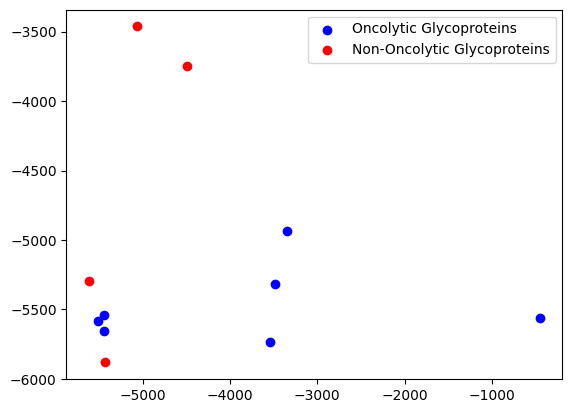

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(oncoScores_oncoHMM, oncoScores_nonOncoHMM, color = 'blue', label = "Oncolytic Glycoproteins")
plt.scatter(nonOncoScores_oncoHMM, nonOncoScores_nonOncoHMM, color = 'red', label = "Non-Oncolytic Glycoproteins")

plt.legend()
plt.show()



In [ ]:
!pip install pyHMMER

In [ ]:
# Sample Sequences
# Sample Sequences
kinAseq = "VAVKTLKDELG-QLFRIVN--FPNVGDLKPQKLSDFGLAIEAAK"
kinBseq = "VVIRTLKDELG--VFKLVH--YPNVDDLKPQKLSDFGLSVESVK"
kinCseq = "IAVKALKGDLG--LFRVTDGLHPGVDDLKPQKLSDFGFAIEAVR"
kinDseq = "VVIKALKDELG--LYKVVN--HPNVDVLKPQKLSDFGLAIEAIR"
kinEseq = "LALKVLKDELGNVLFRVVNEEYPNVNDLKPQKLSDFGLAIEAAR"
kinFseq = "-VLRNLRDDLG--LYKIVN--HPNVEELRPQKLSDFGIAIDAVK"

# Combining them into an iterable dataframe
seqs = [kinAseq, kinBseq, kinCseq, kinDseq, kinEseq, kinFseq]
seqDF = pd.DataFrame(list(seq) for seq in seqs)

In [ ]:
# Validating the HMM compared to pyHMMER
import pyhmmer as ph

# Building the pyHMMER HMM
alphabet = ph.easel.Alphabet.amino()

phSeqs = []
for seqIDX in range(len(seqs)):
  name = "seq"+str(seqIDX)
  phSeqs.append(ph.easel.TextSequence(name = name.encode('utf-8'), sequence = seqs[seqIDX]))

msa = ph.easel.TextMSA(name = b"msa", sequences = phSeqs)
msa = msa.digitize(alphabet)

builder = ph.plan7.Builder(alphabet)
background = ph.plan7.Background(alphabet)
hmm, _, _ = builder.build_msa(msa, background)


# Building our HMM
myHMM = buildHMM(seqDF)

# Sampling 50 samples from our HMM
samples = []
for i in range(50):
  samples.append(myHMM.sample())

# Getting the scores each HMM generates for the samples
myScores = []
phScores = []
for i in range(50):
  # Finding my scores
  logP, path = myHMM.mostLikely(samples[i])
  myScores.append(logP)

  # Fiding ph scores
  curSeq = ph.easel.TextSequence(sequence = samples[i])
  curSeq = ph.easel.TextSequenceBlock([curSeq])
  curSeq = curSeq.digitize(alphabet)
  hits = next(ph.hmmer.hmmsearch(hmm, curSeq))
  phScores.append(hits[0].score)

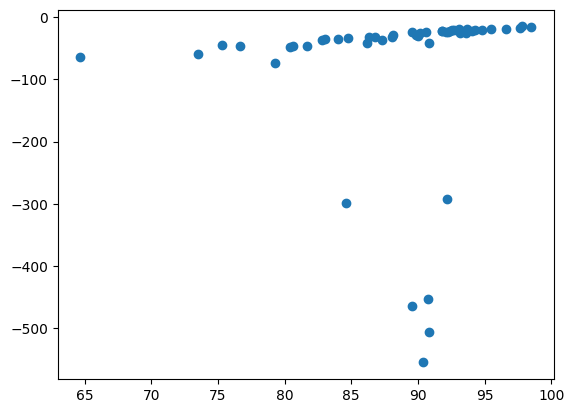

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(phScores, myScores)